Z_CUTS_USE: [-10, 10, 30, 50]


/opt/anaconda3/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/var/folders/vc/8q1m7m693f9ct6h61j_ft6tm0000gn/T/ipykernel_46845/1673002309.py:218: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)
/var/folders/vc/8q1m7m693f9ct6h61j_ft6tm0000gn/T/ipykernel_46845/1673002309.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


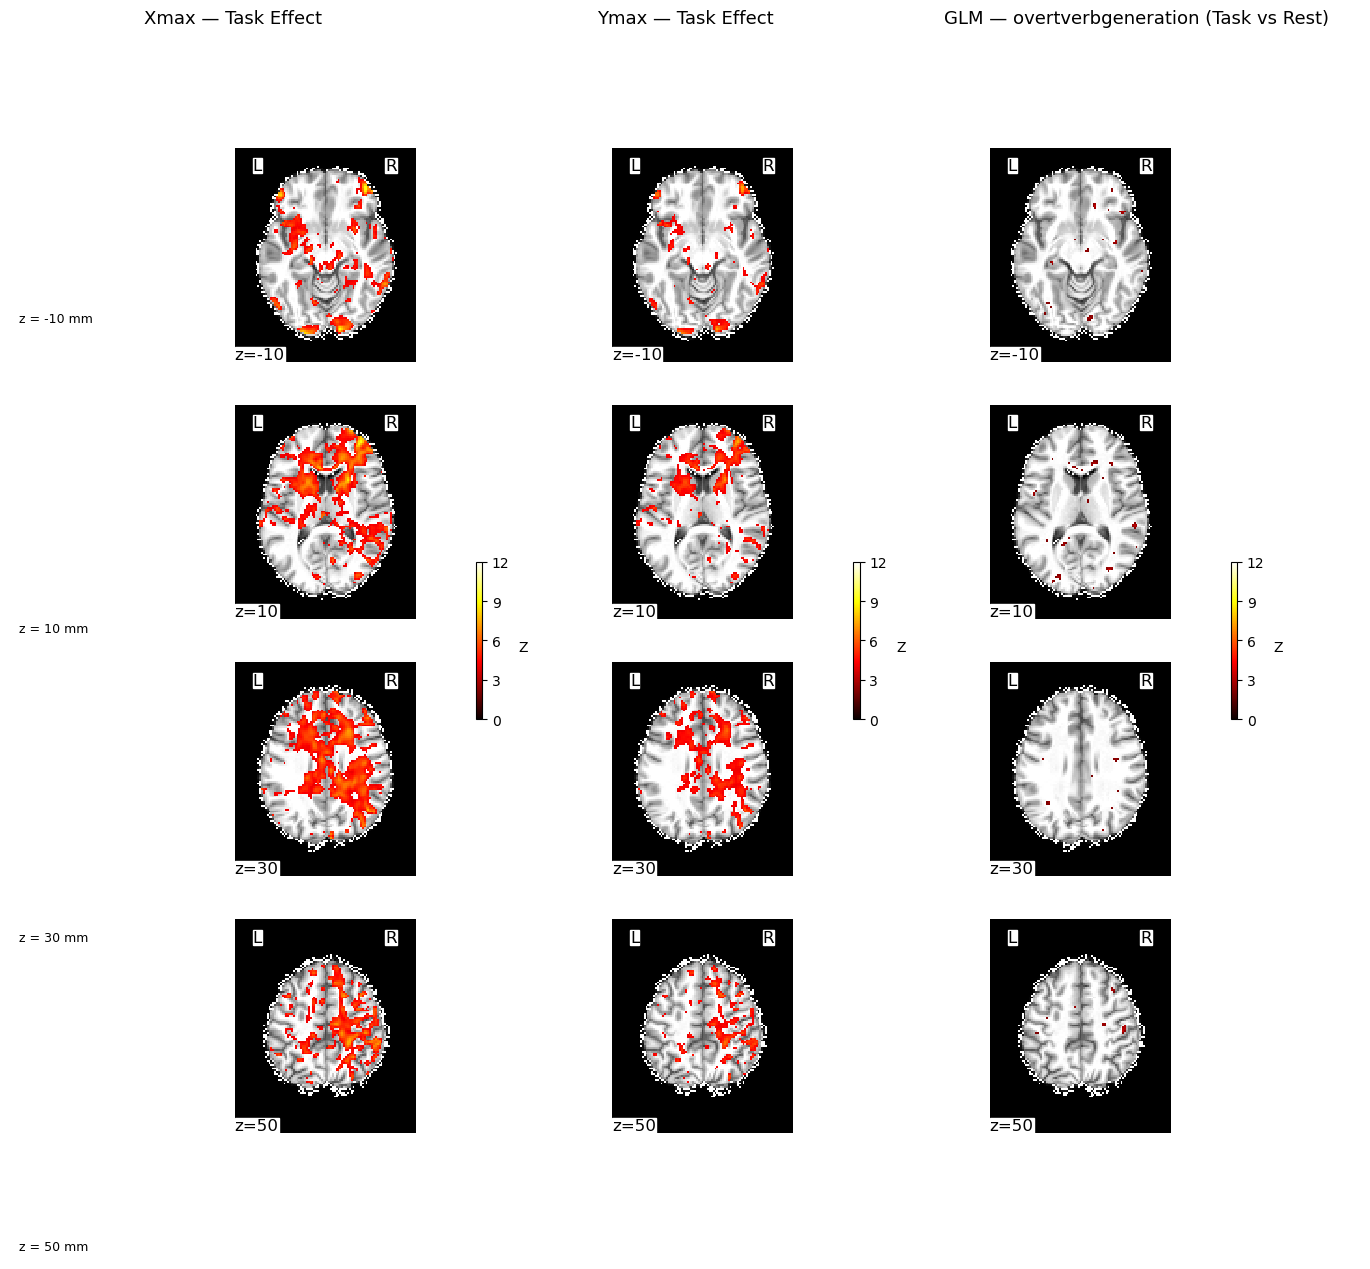

Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_GRID_Task_GLM-overtverbgeneration_masked_4slices.png
Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_GRID_Task_GLM-overtverbgeneration_masked_4slices.pdf


In [19]:
# === TEST-RETEST: Xmax / Ymax / GLM overlay on MNI T1
# === Updated: fixed Z cuts (more cortical), same colormap, cleaner titles,
# ===          and NEW layout: rows = slices, cols = methods (best for paper) ===

import os
from pathlib import Path
import numpy as np
import nibabel as nib
from nilearn import image, plotting, masking
import matplotlib.pyplot as plt

# ---------------- Paths (EDIT ONLY THESE IF NEEDED) ----------------
ROOT     = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI"
OUT_BASE = f"{ROOT}/outputs_tr"

XMAX_DIR = f"{OUT_BASE}/Xmax"
YMAX_DIR = f"{OUT_BASE}/Ymax"
GLM_DIR  = f"{OUT_BASE}/GLM_maps/second_level"

RES_DIR  = f"{ROOT}/results_final_TR"
Path(RES_DIR).mkdir(parents=True, exist_ok=True)

# Anatomical underlay (MNI)
anat_path = (
    f"{ROOT}/fmriprep_output/sub-01/anat/"
    "sub-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz"
)

# Optional preferred mask (if not found, computed from anat)
PREF_MASK = f"{RES_DIR}/brain_mask.nii.gz"

# ---------------- What are we plotting? ----------------
METHODS = ["Xmax", "Ymax", "GLM"]

# X/Y effects available from your files: "Task", "Session", "TaskxSession"
EFFECT = "Task"  # change to "Session" or "TaskxSession"

# GLM task map to compare against (choose one you have)
GLM_TASK = "overtverbgeneration"  # "linebisection" | "overtverbgeneration" | "overtwordrepetition"
GLM_USE_THRESH_MAP = False        # True uses *_thresh.nii.gz

# ---------------- Viz settings ----------------
VMAX = 12.0
THR  = {"GLM": 2.0, "Ymax": 4.0, "Xmax": 4.0}   # adjust if needed
CMAP = "hot"                                    # same cmap for all methods

# ✅ Fixed Z cuts (more cortical / balanced)
# Recommended for most task fMRI comparisons:
#Z_CUTS = [-30, -10, 10, 30, 50]  # edit if you want different slices
Z_CUTS = [-10, 10, 30, 50]  # edit if you want different slices
EXCLUDE_Z_MM = []                # e.g., [-30] to drop one slice

CBAR_TICKS = [0, 3, 6, 9, 12]
TITLE_FONTSIZE = 13
SLICE_LABEL_FONTSIZE = 9

plt.rcParams["figure.facecolor"] = "white"

# ---------------- Helpers ----------------
def first(*paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

def collapse_maxT(in4, out3, vmax_clip=12.0):
    """Collapse 4D -> 3D by max over 4th dim, with clipping for stability."""
    if in4 is None:
        return None
    if os.path.exists(out3):
        return out3
    img4 = image.load_img(in4)
    dat  = img4.get_fdata()
    dat[~np.isfinite(dat)] = -np.inf
    dat = np.clip(dat, -vmax_clip, vmax_clip)
    maxT = np.max(dat, axis=3)
    nib.save(nib.Nifti1Image(maxT.astype("float32"), img4.affine, img4.header), out3)
    return out3

def make_bright_bg(in_path, out_path, lo=2, hi=98, gamma=0.6):
    """Make a bright, publication-friendly background from T1."""
    img = nib.load(in_path)
    data = img.get_fdata()
    p_lo, p_hi = np.percentile(data[np.isfinite(data)], [lo, hi])
    if p_hi <= p_lo:
        p_lo, p_hi = float(np.nanmin(data)), float(np.nanmax(data))
    x = np.clip((data - p_lo) / (p_hi - p_lo + 1e-6), 0, 1)
    x = np.power(x, gamma)
    nib.save(nib.Nifti1Image(x.astype("float32"), img.affine, img.header), out_path)
    return out_path

def load_or_make_mask():
    """Prefer an existing mask; else compute from anatomical template."""
    mpath = first(PREF_MASK)
    if mpath:
        return image.load_img(mpath)
    t1_img = image.load_img(anat_path)
    mask_img = masking.compute_brain_mask(t1_img)
    out = f"{RES_DIR}/brain_mask_from_T1.nii.gz"
    nib.save(mask_img, out)
    return mask_img

def apply_mask_img(stat_path, mask_img):
    """Return masked Nifti1Image where out-of-mask voxels are NaN."""
    s_img = image.load_img(stat_path)
    m_res = image.resample_to_img(mask_img, s_img, interpolation="nearest")
    m = m_res.get_fdata().astype(bool)
    s = s_img.get_fdata()
    s[~m] = np.nan
    return nib.Nifti1Image(s.astype("float32"), s_img.affine, s_img.header)

def pick_map(method):
    """Return a 3D map path for each method."""
    if method == "Xmax":
        in4 = first(f"{XMAX_DIR}/Zta_{EFFECT}_4D.nii.gz", f"{XMAX_DIR}/Zta_{EFFECT}_4D_capped.nii.gz")
        return collapse_maxT(in4, f"{RES_DIR}/Xmax_Zta_{EFFECT}_maxT_3D.nii.gz", vmax_clip=VMAX)

    if method == "Ymax":
        in4 = first(f"{YMAX_DIR}/Z_{EFFECT}_4D.nii.gz", f"{YMAX_DIR}/Z_{EFFECT}_4D_capped.nii.gz")
        return collapse_maxT(in4, f"{RES_DIR}/Ymax_Z_{EFFECT}_maxT_3D.nii.gz", vmax_clip=VMAX)

    if method == "GLM":
        base = f"{GLM_DIR}/{GLM_TASK}"
        return first(
            f"{base}/GROUP_task-{GLM_TASK}_TaskVsRest_zmap_thresh.nii.gz" if GLM_USE_THRESH_MAP else None,
            f"{base}/GROUP_task-{GLM_TASK}_TaskVsRest_zmap.nii.gz",
        )

    return None

# ---------------- Prep background + mask ----------------
BG_IMG   = make_bright_bg(anat_path, f"{RES_DIR}/bg_T1_bright.nii.gz")
MASK_IMG = load_or_make_mask()

# ---------------- Collect maps ----------------
src_maps = {m: pick_map(m) for m in METHODS}
missing = [m for m, p in src_maps.items() if not p]
if missing:
    print("[WARN] Missing maps for:", missing)
    print("Resolved paths:", src_maps)

masked_map = {m: (apply_mask_img(src_maps[m], MASK_IMG) if src_maps[m] else None) for m in METHODS}

# ---------------- Fixed Z cuts with optional exclusions ----------------
badset = {int(round(z)) for z in EXCLUDE_Z_MM}
Z_CUTS_USE = [z for z in Z_CUTS if int(round(z)) not in badset]
if len(Z_CUTS_USE) == 0:
    raise ValueError("All Z_CUTS removed by EXCLUDE_Z_MM. Please adjust.")
print("Z_CUTS_USE:", Z_CUTS_USE)

# ---------------- NEW FIGURE LAYOUT ----------------
# Rows = slices, Cols = methods
n_rows = len(Z_CUTS_USE)
n_cols = len(METHODS)

# Tweak figure size if you want larger panels:
fig_w = 4.6 * n_cols
fig_h = 3.2 * n_rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))

# Ensure axes is 2D array even if 1 row/col
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

# Column titles (cleaner; no "max over 4D -> 3D" in title)
col_titles = {
    "Xmax": f"Xmax — {EFFECT} Effect",
    "Ymax": f"Ymax — {EFFECT} Effect",
    "GLM":  f"GLM — {GLM_TASK} (Task vs Rest)",
}

for i, z in enumerate(Z_CUTS_USE):
    for j, method in enumerate(METHODS):
        ax = axes[i, j]
        ax.axis("off")

        stat_img = masked_map[method]
        if stat_img is None:
            ax.text(0.5, 0.5, f"{method}\n(no map)", ha="center", va="center", fontsize=12)
            continue

        # For paper-style comparison: same single-slice per panel
        disp = plotting.plot_stat_map(
            stat_img,
            bg_img=BG_IMG,
            display_mode="z",
            cut_coords=[z],
            threshold=THR[method],
            vmin=0, vmax=VMAX,
            cmap=CMAP,
            black_bg=False,
            dim=0.0,
            annotate=True,
            colorbar=False,   # we'll add one colorbar per column below
            axes=ax,
        )

        # Add row label (z slice) on the leftmost column only
        if j == 0:
            ax.text(
                0.02, 0.02, f"z = {z:.0f} mm",
                transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=SLICE_LABEL_FONTSIZE,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85),
            )

        # Add column titles on top row only
        if i == 0:
            ax.set_title(col_titles[method], fontsize=TITLE_FONTSIZE, pad=10)

# --- Add one colorbar per column (consistent VMAX) ---
# We reuse a mappable from Matplotlib for clean colorbars.
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=VMAX)
sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)
sm.set_array([])

# Place a colorbar for each column at the right edge of that column
for j, method in enumerate(METHODS):
    # make a colorbar aligned to the whole column
    col_axes = axes[:, j].ravel().tolist()
    cbar = fig.colorbar(
        sm,
        ax=col_axes,
        fraction=0.02,
        pad=0.01,
        shrink=0.92,
        aspect=25,
    )
    cbar.set_ticks(CBAR_TICKS)
    cbar.set_label("Z", rotation=0, labelpad=10)

fig.tight_layout()

# ---------------- Save ----------------
tag = f"{EFFECT}_GLM-{GLM_TASK}"
out_png = f"{RES_DIR}/fig_TR_GRID_{tag}_masked_{len(Z_CUTS_USE)}slices.png"
out_pdf = f"{RES_DIR}/fig_TR_GRID_{tag}_masked_{len(Z_CUTS_USE)}slices.pdf"

fig.savefig(out_png, dpi=600, bbox_inches="tight")
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)

# ---------------- NOTE FOR CAPTION (not printed) ----------------
# Xmax/Ymax maps shown are max-over-4D collapsed to 3D before plotting.
# (Keep this statement in your manuscript caption/methods, not as figure title.)


Resolved paths: {'Xmax': '/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/Xmax_Zta_Task_maxT_3D.nii.gz', 'Ymax': '/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/Ymax_Z_Task_maxT_3D.nii.gz', 'GLM': '/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/GLM_omnibus_max_4tasks_zmap.nii.gz'}
Z_CUTS_USE: [-10, 10, 30, 50]


/opt/anaconda3/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/var/folders/vc/8q1m7m693f9ct6h61j_ft6tm0000gn/T/ipykernel_12287/3269448077.py:273: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)
/var/folders/vc/8q1m7m693f9ct6h61j_ft6tm0000gn/T/ipykernel_12287/3269448077.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


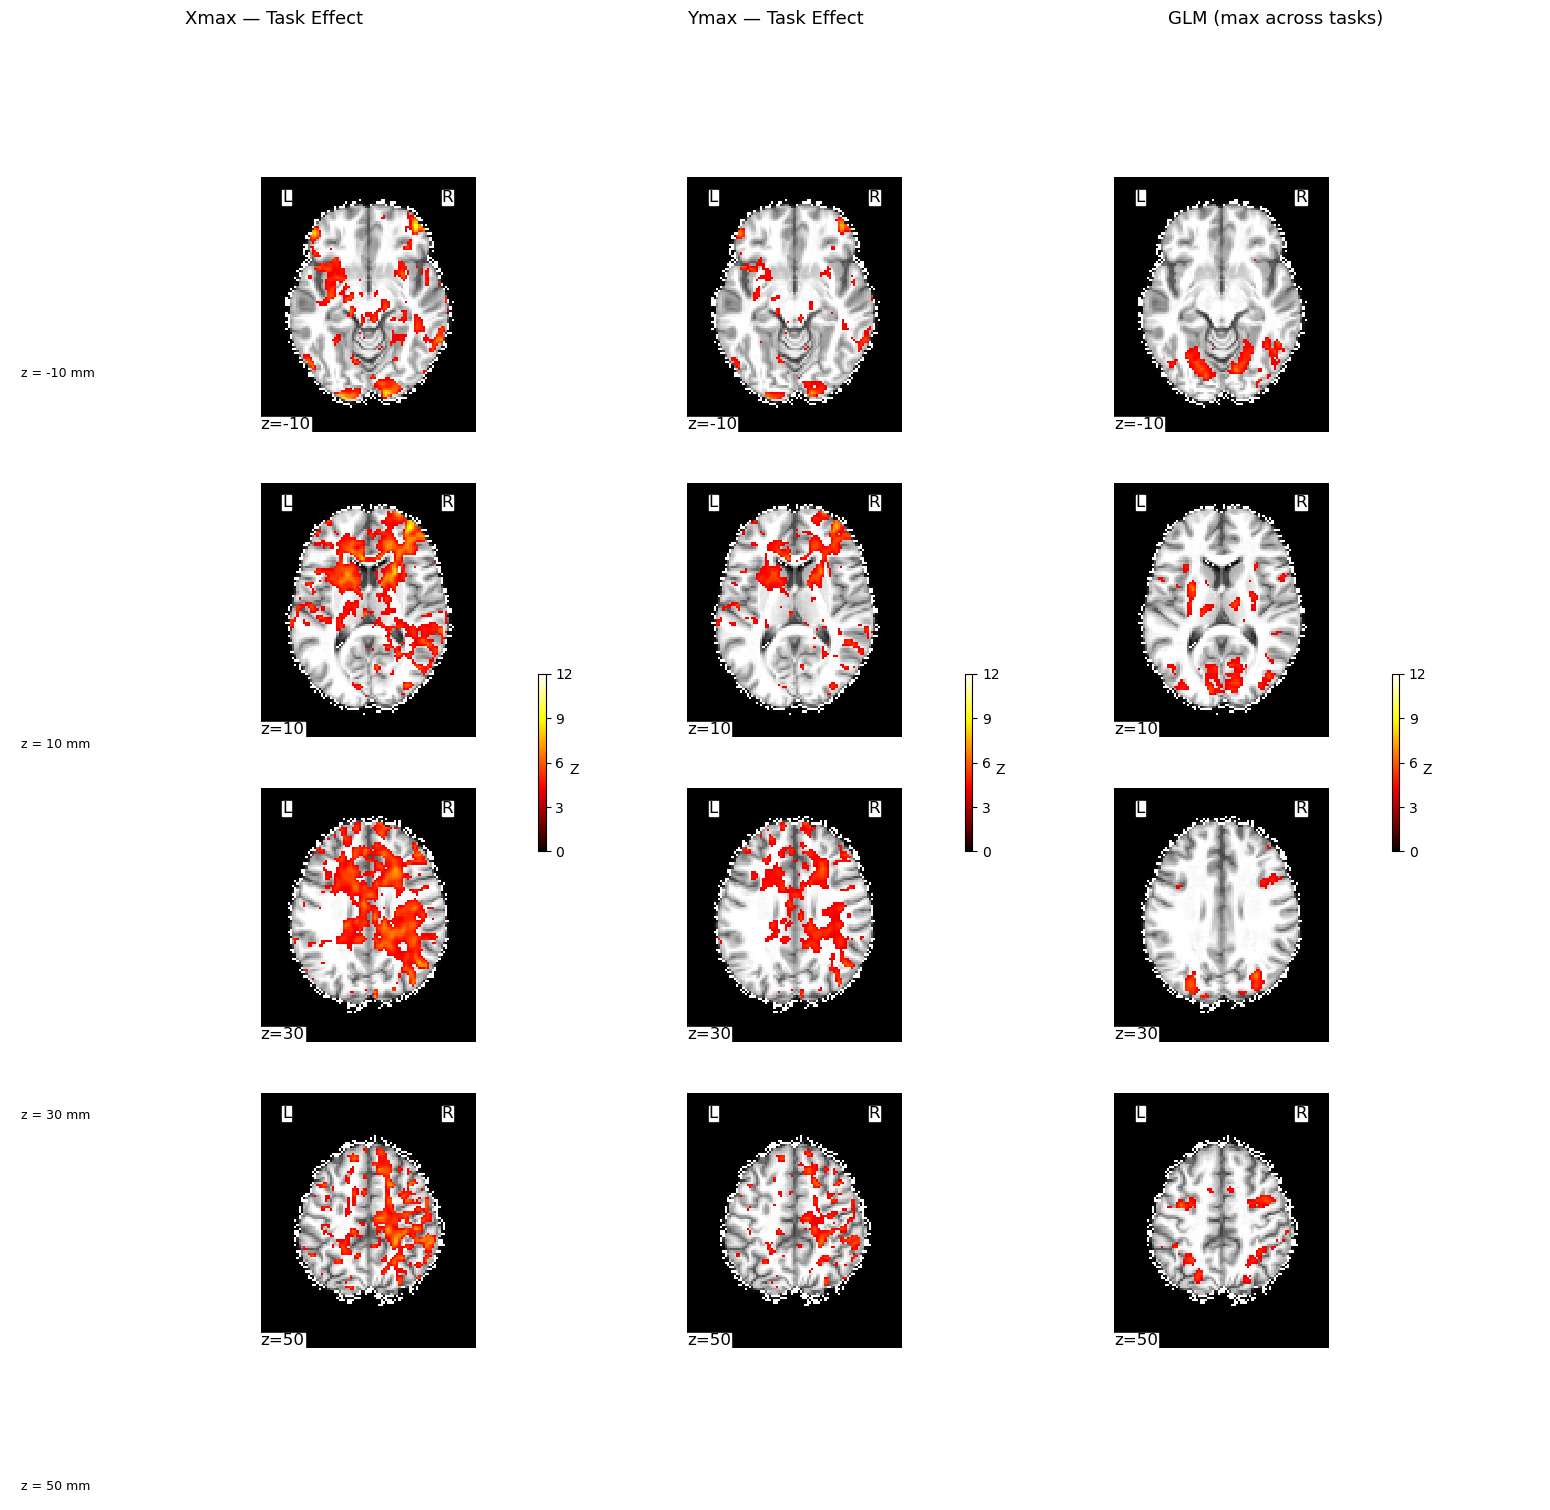

Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_GRID_Task_GLM-omnibus-max_4tasks_masked_4slices.png
Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_GRID_Task_GLM-omnibus-max_4tasks_masked_4slices.pdf


In [3]:
# === TEST-RETEST: Xmax / Ymax / GLM (OMNIBUS across tasks) overlay on MNI T1
# === Updated per your request:
#     1) GLM column is now a SINGLE omnibus map combining multiple GLM task z-maps
#     2) Combination mode default = MAX across tasks (easy comparison; max-type like X/Y)
#     3) Fixed Z cuts (more cortical)
#     4) Same colormap across methods
#     5) Grid layout: rows = slices, cols = methods (Xmax | Ymax | GLM-Omnibus)

import os
from pathlib import Path
import numpy as np
import nibabel as nib
from nilearn import image, plotting, masking
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------- Paths ----------------
ROOT     = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI"
OUT_BASE = f"{ROOT}/outputs_tr"

XMAX_DIR = f"{OUT_BASE}/Xmax"
YMAX_DIR = f"{OUT_BASE}/Ymax"
GLM_DIR  = f"{OUT_BASE}/GLM_maps/second_level"

RES_DIR  = f"{ROOT}/results_final_TR"
Path(RES_DIR).mkdir(parents=True, exist_ok=True)

# Anatomical underlay (MNI). Adjust sub-01 path if your fmriprep_output differs.
anat_path = (
    f"{ROOT}/fmriprep_output/sub-01/anat/"
    "sub-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz"
)

# Optional preferred mask; if not found, computed from anat
PREF_MASK = f"{RES_DIR}/brain_mask.nii.gz"

# ---------------- Analysis choices ----------------
METHODS = ["Xmax", "Ymax", "GLM"]

# Available for X/Y: "Task", "Session", "TaskxSession"
EFFECT = "Task"  # change as needed

# GLM tasks to include in omnibus map:
# Add/remove tasks based on what exists in outputs_tr/GLM_maps/second_level/<task>/
GLM_TASKS = [
    "linebisection",
    "overtverbgeneration",
    "overtwordrepetition",
    "fingerfootlips",  # uncomment if you have this folder + group zmap
]

# How to combine GLM tasks:
#  - "max"     : voxelwise max across task z-maps (recommended for easy comparison)
#  - "stouffer": sum(Z)/sqrt(k) (meta-analytic-ish)
GLM_MODE = "max"

# ---------------- Viz settings ----------------
VMAX = 12.0
THR  = {"GLM": 4.0, "Ymax": 4.0, "Xmax": 4.0}
CMAP = "hot"  # same for all

# Fixed Z cuts (balanced cortex + subcortex)
Z_CUTS = [-10, 10, 30, 50]
EXCLUDE_Z_MM = []  # e.g. [-30] to drop

CBAR_TICKS = [0, 3, 6, 9, 12]
TITLE_FONTSIZE = 13
SLICE_LABEL_FONTSIZE = 9

plt.rcParams["figure.facecolor"] = "white"

# ---------------- Helpers ----------------
def first(*paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

def collapse_maxT(in4, out3, vmax_clip=12.0):
    """Collapse 4D -> 3D by max over 4th dim, with clipping for stability."""
    if in4 is None:
        return None
    if os.path.exists(out3):
        return out3
    img4 = image.load_img(in4)
    dat  = img4.get_fdata()
    dat[~np.isfinite(dat)] = -np.inf
    dat = np.clip(dat, -vmax_clip, vmax_clip)
    maxT = np.max(dat, axis=3)
    nib.save(nib.Nifti1Image(maxT.astype("float32"), img4.affine, img4.header), out3)
    return out3

def make_bright_bg(in_path, out_path, lo=2, hi=98, gamma=0.6):
    """Make a bright, publication-friendly background from T1."""
    img = nib.load(in_path)
    data = img.get_fdata()
    p_lo, p_hi = np.percentile(data[np.isfinite(data)], [lo, hi])
    if p_hi <= p_lo:
        p_lo, p_hi = float(np.nanmin(data)), float(np.nanmax(data))
    x = np.clip((data - p_lo) / (p_hi - p_lo + 1e-6), 0, 1)
    x = np.power(x, gamma)
    nib.save(nib.Nifti1Image(x.astype("float32"), img.affine, img.header), out_path)
    return out_path

def load_or_make_mask():
    """Prefer an existing mask; else compute from anatomical template."""
    mpath = first(PREF_MASK)
    if mpath:
        return image.load_img(mpath)
    t1_img = image.load_img(anat_path)
    mask_img = masking.compute_brain_mask(t1_img)
    out = f"{RES_DIR}/brain_mask_from_T1.nii.gz"
    nib.save(mask_img, out)
    return mask_img

def apply_mask_img(stat_img_or_path, mask_img):
    """Return masked Nifti1Image where out-of-mask voxels are NaN."""
    s_img = stat_img_or_path if hasattr(stat_img_or_path, "get_fdata") else image.load_img(stat_img_or_path)
    m_res = image.resample_to_img(mask_img, s_img, interpolation="nearest")
    m = m_res.get_fdata().astype(bool)
    s = s_img.get_fdata()
    s[~m] = np.nan
    return nib.Nifti1Image(s.astype("float32"), s_img.affine, s_img.header)

# ---------------- GLM omnibus builder ----------------
def pick_glm_task_map(task):
    base = f"{GLM_DIR}/{task}"
    return first(
        f"{base}/GROUP_task-{task}_TaskVsRest_zmap.nii.gz",
        f"{base}/GROUP_task-{task}_TaskVsRest_zmap_thresh.nii.gz",
    )

def build_glm_omnibus(tasks, out_path, mode="max"):
    """
    Build a single GLM omnibus map from multiple task group z-maps.
    mode:
      - "max": voxelwise max across tasks (recommended for easy comparison)
      - "stouffer": sum(Z)/sqrt(k)
    """
    task_paths = []
    missing_tasks = []
    for t in tasks:
        p = pick_glm_task_map(t)
        if p:
            task_paths.append(p)
        else:
            missing_tasks.append(t)

    if missing_tasks:
        print("[WARN] Missing GLM task maps for:", missing_tasks)

    if len(task_paths) == 0:
        return None

    if os.path.exists(out_path):
        return out_path

    imgs = [image.load_img(p) for p in task_paths]
    ref  = imgs[0]
    imgs = [image.resample_to_img(im, ref, interpolation="continuous") for im in imgs]

    data = np.stack([im.get_fdata() for im in imgs], axis=0)
    data[~np.isfinite(data)] = np.nan

    if mode == "max":
        out = np.nanmax(data, axis=0)
    elif mode == "stouffer":
        k = data.shape[0]
        out = np.nansum(data, axis=0) / np.sqrt(k)
    else:
        raise ValueError("GLM_MODE must be 'max' or 'stouffer'")

    nib.save(nib.Nifti1Image(out.astype("float32"), ref.affine, ref.header), out_path)
    return out_path

# ---------------- Map picker ----------------
def pick_map(method):
    """Return a 3D map path for each method."""
    if method == "Xmax":
        in4 = first(f"{XMAX_DIR}/Zta_{EFFECT}_4D.nii.gz", f"{XMAX_DIR}/Zta_{EFFECT}_4D_capped.nii.gz")
        return collapse_maxT(in4, f"{RES_DIR}/Xmax_Zta_{EFFECT}_maxT_3D.nii.gz", vmax_clip=VMAX)

    if method == "Ymax":
        in4 = first(f"{YMAX_DIR}/Z_{EFFECT}_4D.nii.gz", f"{YMAX_DIR}/Z_{EFFECT}_4D_capped.nii.gz")
        return collapse_maxT(in4, f"{RES_DIR}/Ymax_Z_{EFFECT}_maxT_3D.nii.gz", vmax_clip=VMAX)

    if method == "GLM":
        out = f"{RES_DIR}/GLM_omnibus_{GLM_MODE}_{len(GLM_TASKS)}tasks_zmap.nii.gz"
        return build_glm_omnibus(GLM_TASKS, out_path=out, mode=GLM_MODE)

    return None

# ---------------- Prep background + mask ----------------
BG_IMG   = make_bright_bg(anat_path, f"{RES_DIR}/bg_T1_bright.nii.gz")
MASK_IMG = load_or_make_mask()

# ---------------- Collect and mask maps ----------------
src_maps = {m: pick_map(m) for m in METHODS}
missing = [m for m, p in src_maps.items() if not p]
if missing:
    print("[WARN] Missing maps for:", missing)
print("Resolved paths:", src_maps)

masked_map = {m: (apply_mask_img(src_maps[m], MASK_IMG) if src_maps[m] else None) for m in METHODS}

# ---------------- Z cuts ----------------
badset = {int(round(z)) for z in EXCLUDE_Z_MM}
Z_CUTS_USE = [z for z in Z_CUTS if int(round(z)) not in badset]
if len(Z_CUTS_USE) == 0:
    raise ValueError("All Z_CUTS removed by EXCLUDE_Z_MM. Please adjust.")
print("Z_CUTS_USE:", Z_CUTS_USE)

# ---------------- Figure (rows = slices, cols = methods) ----------------
n_rows = len(Z_CUTS_USE)
n_cols = len(METHODS)

fig_w = 5.2 * n_cols
fig_h = 3.8 * n_rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))

# Ensure axes is 2D array
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

col_titles = {
    "Xmax": f"Xmax — {EFFECT} Effect",
    "Ymax": f"Ymax — {EFFECT} Effect",
    "GLM":  f"GLM ({GLM_MODE} across tasks)",
}

for i, z in enumerate(Z_CUTS_USE):
    for j, method in enumerate(METHODS):
        ax = axes[i, j]
        ax.axis("off")
        stat_img = masked_map[method]

        if stat_img is None:
            ax.text(0.5, 0.5, f"{method}\n(no map)", ha="center", va="center", fontsize=12)
            continue

        plotting.plot_stat_map(
            stat_img,
            bg_img=BG_IMG,
            display_mode="z",
            cut_coords=[z],
            threshold=THR[method],
            vmin=0, vmax=VMAX,
            cmap=CMAP,
            black_bg=False,
            dim=0.0,
            annotate=True,    # keep L/R
            colorbar=False,   # one per column below
            axes=ax,
        )

        # Row slice label on leftmost column only (avoid duplicate labels)
        if j == 0:
            ax.text(
                0.02, 0.02, f"z = {z:.0f} mm",
                transform=ax.transAxes, ha="left", va="bottom",
                fontsize=SLICE_LABEL_FONTSIZE,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85),
            )

        # Column title on top row only
        if i == 0:
            ax.set_title(col_titles[method], fontsize=TITLE_FONTSIZE, pad=5)

# ---------------- One colorbar per column ----------------
norm = mpl.colors.Normalize(vmin=0, vmax=VMAX)
sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)
sm.set_array([])

for j, method in enumerate(METHODS):
    col_axes = axes[:, j].ravel().tolist()
    cbar = fig.colorbar(
        sm,
        ax=col_axes,
        fraction=0.02,
        pad=0.10,
        shrink=1.0,
        aspect=25,
    )
    cbar.set_ticks(CBAR_TICKS)
    cbar.set_label("Z", rotation=0, labelpad=0.5)

fig.tight_layout()

# ---------------- Save ----------------
tasks_tag = "-".join([t[:8] for t in GLM_TASKS])  # short tag
tag = f"{EFFECT}_GLM-omnibus-{GLM_MODE}_{len(GLM_TASKS)}tasks"
out_png = f"{RES_DIR}/fig_TR_GRID_{tag}_masked_{len(Z_CUTS_USE)}slices.png"
out_pdf = f"{RES_DIR}/fig_TR_GRID_{tag}_masked_{len(Z_CUTS_USE)}slices.pdf"

fig.savefig(out_png, dpi=600, bbox_inches="tight")
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)

# ---------------- Caption note (put in manuscript, not figure title) ----------------
# - Xmax/Ymax: 4D maps collapsed to 3D by voxelwise maximum over the 4th dimension prior to plotting.
# - GLM omnibus: voxelwise combination across task-specific second-level z-maps using GLM_MODE.


/opt/anaconda3/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/var/folders/vc/8q1m7m693f9ct6h61j_ft6tm0000gn/T/ipykernel_12287/1469973205.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.96, 1])


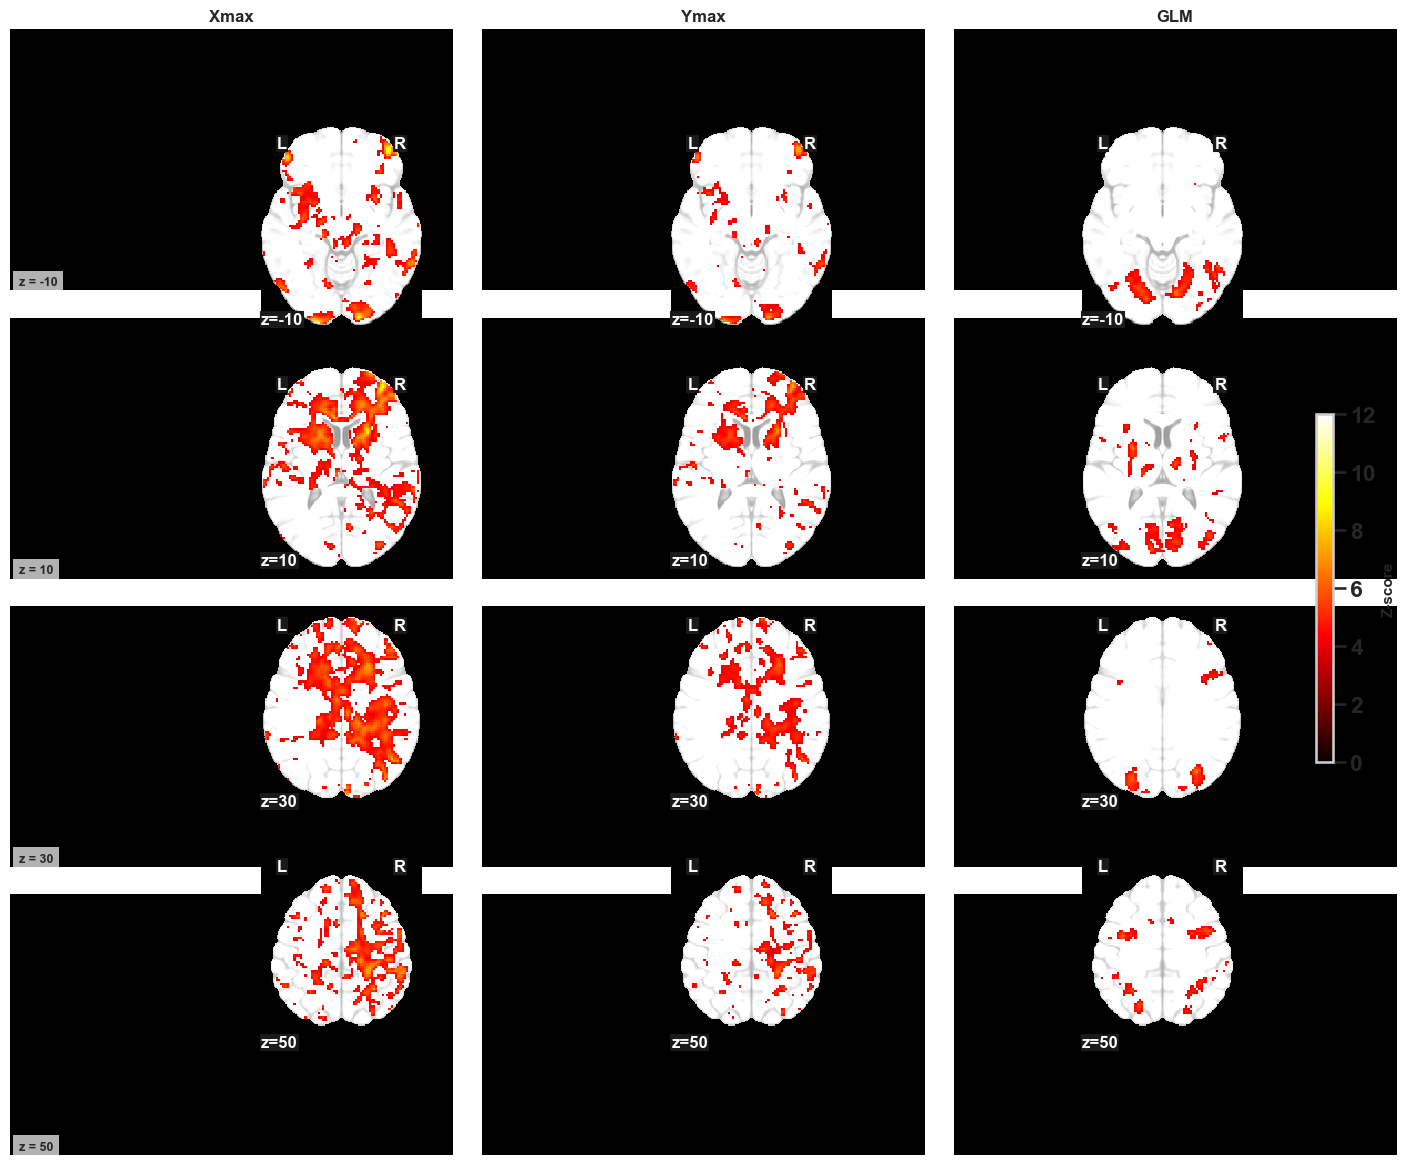

Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/FINAL_MNI_FIG_PUBLICATION.png


In [59]:
# === TEST-RETEST: Xmax / Ymax / GLM (OMNIBUS across tasks) overlay on MNI T1

import os
from pathlib import Path
import numpy as np
import nibabel as nib
from nilearn import image, plotting, masking, datasets
from nilearn.image import smooth_img
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------- Paths ----------------
ROOT     = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI"
OUT_BASE = f"{ROOT}/outputs_tr"

XMAX_DIR = f"{OUT_BASE}/Xmax"
YMAX_DIR = f"{OUT_BASE}/Ymax"
GLM_DIR  = f"{OUT_BASE}/GLM_maps/second_level"

RES_DIR  = f"{ROOT}/results_final_TR"
Path(RES_DIR).mkdir(parents=True, exist_ok=True)

# =========================
# LOAD HIGH-RES TEMPLATE
# =========================
template = datasets.load_mni152_template(resolution=1)
anat_path = template

# Optional preferred mask
PREF_MASK = f"{RES_DIR}/brain_mask.nii.gz"

# ---------------- Analysis choices ----------------
METHODS = ["Xmax", "Ymax", "GLM"]
EFFECT = "Task"

GLM_TASKS = [
    "linebisection",
    "overtverbgeneration",
    "overtwordrepetition",
    "fingerfootlips",
]

GLM_MODE = "max"

# ---------------- Viz settings ----------------
VMAX = 12.0
THR  = {"GLM": 4.0, "Ymax": 4.0, "Xmax": 4.0}
CMAP = "hot"

Z_CUTS = [-10, 10, 30, 50]

plt.rcParams["figure.facecolor"] = "white"

# ---------------- Helpers ----------------
def first(*paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

def collapse_maxT(in4, out3, vmax_clip=12.0):
    if in4 is None:
        return None
    if os.path.exists(out3):
        return out3
    img4 = image.load_img(in4)
    dat  = img4.get_fdata()
    dat[~np.isfinite(dat)] = -np.inf
    dat = np.clip(dat, -vmax_clip, vmax_clip)
    maxT = np.max(dat, axis=3)
    nib.save(nib.Nifti1Image(maxT.astype("float32"), img4.affine, img4.header), out3)
    return out3

def make_bright_bg(in_img, out_path, lo=1, hi=99, gamma=0.5):
    img = image.load_img(in_img)
    data = img.get_fdata()
    p_lo, p_hi = np.percentile(data[np.isfinite(data)], [lo, hi])
    x = np.clip((data - p_lo) / (p_hi - p_lo + 1e-6), 0, 1)
    x = np.power(x, gamma)
    nib.save(nib.Nifti1Image(x.astype("float32"), img.affine, img.header), out_path)
    return out_path

def load_or_make_mask():
    if os.path.exists(PREF_MASK):
        return image.load_img(PREF_MASK)
    t1_img = image.load_img(anat_path)
    mask_img = masking.compute_brain_mask(t1_img)
    out = f"{RES_DIR}/brain_mask_from_T1.nii.gz"
    nib.save(mask_img, out)
    return mask_img

def apply_mask_img(stat_img_or_path, mask_img):
    s_img = image.load_img(stat_img_or_path)
    m_res = image.resample_to_img(mask_img, s_img, interpolation="nearest")
    m = m_res.get_fdata().astype(bool)
    s = s_img.get_fdata()
    s[~m] = np.nan
    return nib.Nifti1Image(s.astype("float32"), s_img.affine, s_img.header)

# ---------------- GLM OMNIBUS ----------------
def pick_glm_task_map(task):
    base = f"{GLM_DIR}/{task}"
    return first(
        f"{base}/GROUP_task-{task}_TaskVsRest_zmap.nii.gz",
        f"{base}/GROUP_task-{task}_TaskVsRest_zmap_thresh.nii.gz",
    )

def build_glm_omnibus(tasks, out_path, mode="max"):
    task_paths = [pick_glm_task_map(t) for t in tasks if pick_glm_task_map(t)]

    if len(task_paths) == 0:
        return None

    if os.path.exists(out_path):
        return out_path

    imgs = [image.load_img(p) for p in task_paths]
    ref  = imgs[0]
    imgs = [image.resample_to_img(im, ref) for im in imgs]

    data = np.stack([im.get_fdata() for im in imgs], axis=0)

    if mode == "max":
        out = np.nanmax(data, axis=0)
    else:
        out = np.nansum(data, axis=0) / np.sqrt(data.shape[0])

    nib.save(nib.Nifti1Image(out.astype("float32"), ref.affine), out_path)
    return out_path

# ---------------- Map picker ----------------
def pick_map(method):
    if method == "Xmax":
        in4 = first(f"{XMAX_DIR}/Zta_{EFFECT}_4D.nii.gz")
        return collapse_maxT(in4, f"{RES_DIR}/Xmax_3D.nii.gz")

    if method == "Ymax":
        in4 = first(f"{YMAX_DIR}/Z_{EFFECT}_4D.nii.gz")
        return collapse_maxT(in4, f"{RES_DIR}/Ymax_3D.nii.gz")

    if method == "GLM":
        return build_glm_omnibus(
            GLM_TASKS,
            f"{RES_DIR}/GLM_omnibus.nii.gz",
            GLM_MODE,
        )

# ---------------- Prep ----------------
BG_IMG   = make_bright_bg(anat_path, f"{RES_DIR}/bg_T1.nii.gz")
MASK_IMG = load_or_make_mask()

# 🔥 Smooth + mask
masked = {}
for m in METHODS:
    mp = pick_map(m)
    if mp:
        smoothed = smooth_img(mp, fwhm=1.5)
        masked[m] = apply_mask_img(smoothed, MASK_IMG)

# ---------------- Plot ----------------
fig, axes = plt.subplots(len(Z_CUTS), len(METHODS), figsize=(15, 12))

title_map = {
    "Xmax": "Xmax",
    "Ymax": "Ymax",
    "GLM":  "GLM"
}

for i, z in enumerate(Z_CUTS):
    for j, method in enumerate(METHODS):
        ax = axes[i, j]

        if method not in masked:
            ax.axis("off")
            continue

        plotting.plot_stat_map(
            masked[method],
            bg_img=BG_IMG,
            display_mode="z",
            cut_coords=[z],
            threshold=THR[method],
            cmap=CMAP,
            vmin=0,
            vmax=VMAX,
            dim=-0.3,
            annotate=True,
            axes=ax,
            colorbar=False,
        )

        # Column titles
        if i == 0:
            ax.set_title(title_map[method], fontsize=12, pad=6)

        # Row slice labels
        if j == 0:
            ax.text(
                0.02, 0.02,
                f"z = {z}",
                transform=ax.transAxes,
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

# ---------------- Colorbar ----------------
norm = mpl.colors.Normalize(vmin=0, vmax=VMAX)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=CMAP)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.015,
    pad=0.02
)
cbar.set_label("Z-score", fontsize=11)

# ---------------- Layout ----------------
plt.tight_layout(rect=[0, 0, 0.96, 1])

# ---------------- Save ----------------
out_file = f"{RES_DIR}/FINAL_MNI_FIG_PUBLICATION.png"
plt.savefig(out_file, dpi=600, bbox_inches='tight')
plt.show()

print("Saved:", out_file)

/var/folders/vc/8q1m7m693f9ct6h61j_ft6tm0000gn/T/ipykernel_12287/1329420717.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)


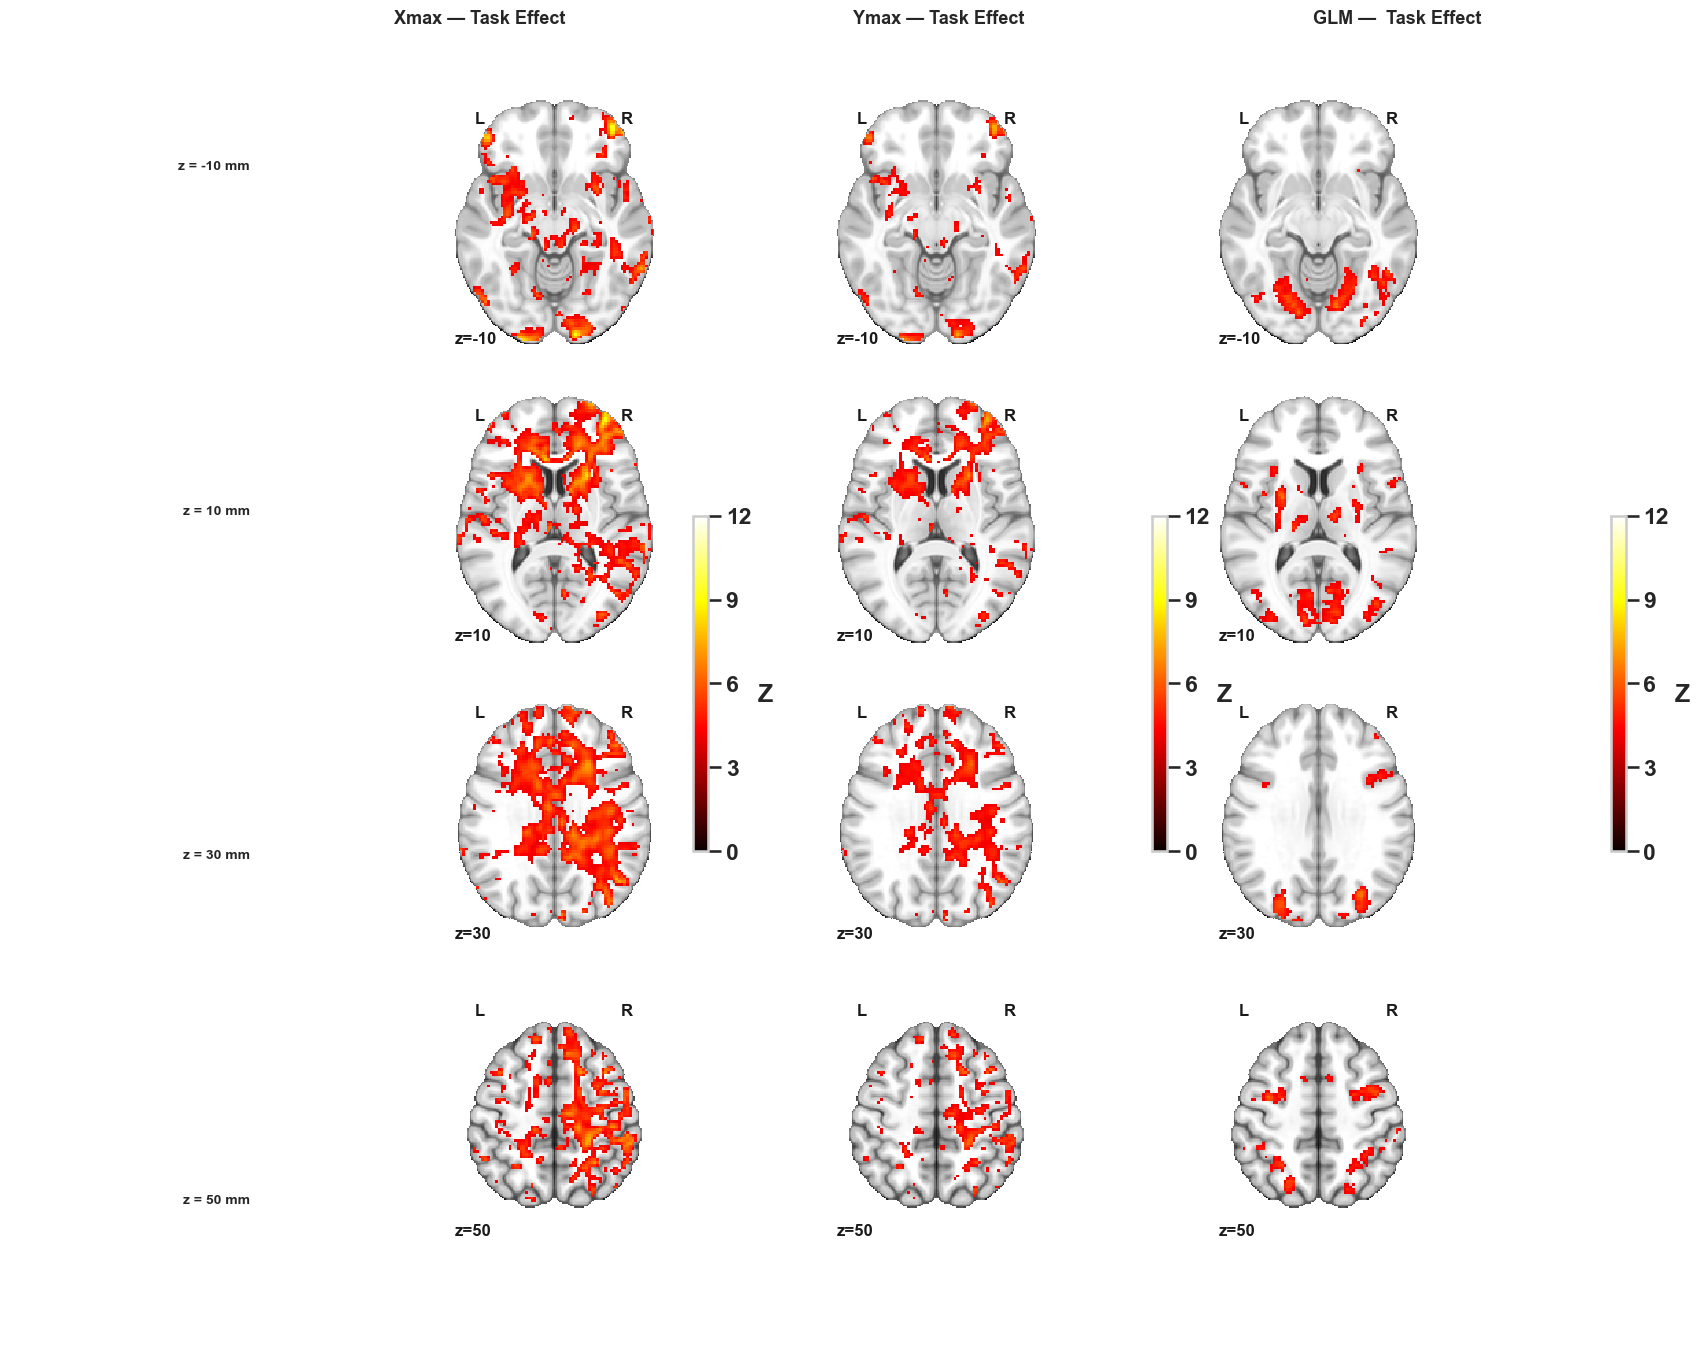

Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_GRID_Task_GLM-omnibus-max_4tasks_masked_4slices.png
Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_GRID_Task_GLM-omnibus-max_4tasks_masked_4slices.pdf


In [61]:
# ================================
# FIGURE (FINAL TIGHT + ALIGNED Z LABEL COLUMN)
#   - close top/title gap
#   - aligned z labels (dedicated left label column)
#   - longer colorbars
#   - bold fonts everywhere
# ================================

import matplotlib as mpl
mpl.rcParams["font.weight"] = "bold"
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.labelweight"] = "bold"

# ---- layout ----
n_rows = len(Z_CUTS_USE)
n_cols = len(METHODS)

# Add ONE extra column for z-labels on the far left
LABEL_COL = 1
TOTAL_COLS = n_cols + LABEL_COL

fig_w = 5.3 * n_cols + 1.2   # +1.2 inches for label column
fig_h = 3.7 * n_rows
fig = plt.figure(figsize=(fig_w, fig_h))

# Grid: label column is narrow; method columns are wider
# width ratios: [label, Xmax, Ymax, GLM]
gs = fig.add_gridspec(
    n_rows, TOTAL_COLS,
    width_ratios=[0.55] + [1.0]*n_cols,
    height_ratios=[1.0]*n_rows
)

# Create axes matrix: left label axes + method axes
label_axes = []
axes = np.empty((n_rows, n_cols), dtype=object)

for i in range(n_rows):
    # label axis (left column)
    lax = fig.add_subplot(gs[i, 0])
    lax.axis("off")
    label_axes.append(lax)

    # method axes
    for j in range(n_cols):
        ax = fig.add_subplot(gs[i, j+1])
        ax.axis("off")
        axes[i, j] = ax

col_titles = {
    "Xmax": f"Xmax — {EFFECT} Effect",
    "Ymax": f"Ymax — {EFFECT} Effect",
    "GLM":  f"GLM —  {EFFECT} Effect",
}

# ---- draw panels ----
for i, z in enumerate(Z_CUTS_USE):

    # Perfectly aligned z-label in its own column (centered vertically)
    label_axes[i].text(
        1.0, 0.5, f"z = {z:.0f} mm",
        ha="right", va="center",
        fontsize=SLICE_LABEL_FONTSIZE + 1,
        fontweight="bold"
    )

    for j, method in enumerate(METHODS):
        ax = axes[i, j]
        stat_img = masked_map[method]

        if stat_img is None:
            ax.text(
                0.5, 0.5, f"{method}\n(no map)",
                ha="center", va="center",
                fontsize=12, fontweight="bold"
            )
            continue

        plotting.plot_stat_map(
            stat_img,
            bg_img=BG_IMG,
            display_mode="z",
            cut_coords=[z],
            threshold=THR[method],
            vmin=0, vmax=VMAX,
            cmap=CMAP,
            black_bg=False,
            dim=0.0,
            annotate=True,      # keep L/R markers
            colorbar=False,     # one per column below
            axes=ax,
        )

        # Column titles only on top row — tighter pad
        if i == 0:
            ax.set_title(
                col_titles[method],
                fontsize=TITLE_FONTSIZE,
                fontweight="bold",
                pad=1  # small pad
            )

# ---- manual spacing (NO tight_layout) ----
# Close top/title gap and tighten grid spacing
fig.subplots_adjust(
    left=0.04, right=0.985,
    top=0.93, bottom=0.04,
    wspace=0.06, hspace=0.22
)

# ---- colorbars (one per method column, longer) ----
norm = mpl.colors.Normalize(vmin=0, vmax=VMAX)
sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)
sm.set_array([])

for j, method in enumerate(METHODS):
    # colorbar belongs to that column's axes (all rows for that method)
    col_axes = axes[:, j].ravel().tolist()

    cbar = fig.colorbar(
        sm,
        ax=col_axes,
        fraction=0.035,  # width
        pad=0.015,
        shrink=1.12,     # longer bar
        aspect=22
    )
    cbar.set_ticks(CBAR_TICKS)
    cbar.set_label("Z", rotation=0, labelpad=10, fontweight="bold")

    for tick in cbar.ax.get_yticklabels():
        tick.set_fontweight("bold")

# ---------------- Save ----------------
tag = f"{EFFECT}_GLM-omnibus-{GLM_MODE}_{len(GLM_TASKS)}tasks"
out_png = f"{RES_DIR}/fig_TR_GRID_{tag}_masked_{len(Z_CUTS_USE)}slices.png"
out_pdf = f"{RES_DIR}/fig_TR_GRID_{tag}_masked_{len(Z_CUTS_USE)}slices.pdf"

fig.savefig(out_png, dpi=600, bbox_inches="tight")
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)


Xmax range: -12.0 9.302002906799316
Ymax range: -12.0 7.741718292236328
GLM range: -5.800907611846924 6.786838531494141


/opt/anaconda3/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/var/folders/vc/8q1m7m693f9ct6h61j_ft6tm0000gn/T/ipykernel_12287/1543095050.py:155: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)


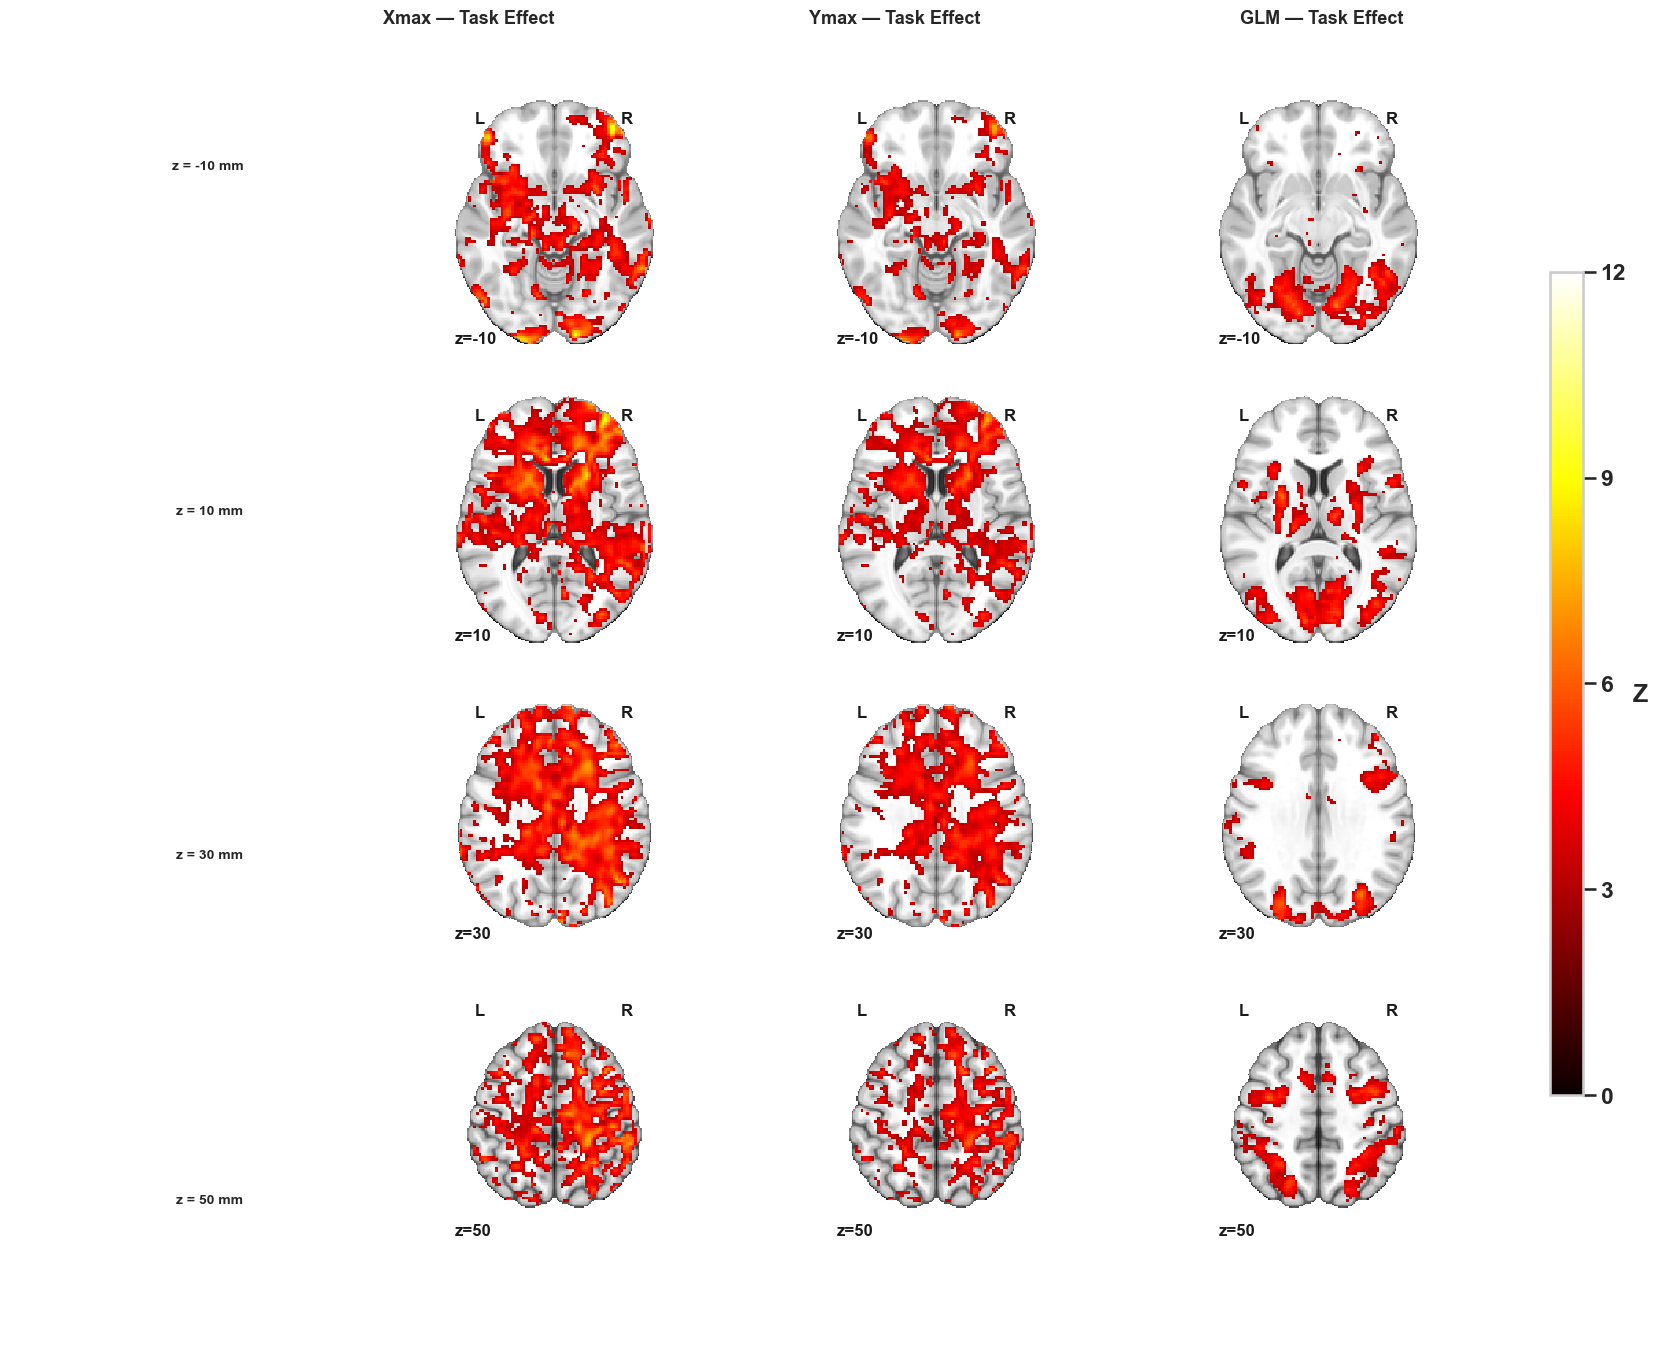

Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_GRID_Task_GLM-omnibus-max_4tasks_masked_4slices.png
Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_GRID_Task_GLM-omnibus-max_4tasks_masked_4slices.pdf


In [65]:
# ================================
# FIGURE (ROBUST + GLOBAL COLORBAR)
#   ✔ avoids blank plots
#   ✔ safe thresholding
#   ✔ single colorbar
# ================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import nibabel as nib

mpl.rcParams["font.weight"] = "bold"
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.labelweight"] = "bold"

# ---------------- SETTINGS ----------------
THR = 3.0   # base threshold (auto-adjusted if needed)

# ---------------- SAFE MASK FUNCTION ----------------
def apply_mask_img_safe(stat_img_or_path, mask_img):
    from nilearn import image

    s_img = image.load_img(stat_img_or_path)
    m_res = image.resample_to_img(mask_img, s_img, interpolation="nearest")

    m = m_res.get_fdata().astype(bool)
    s = s_img.get_fdata()

    # If mask is empty → skip masking
    if np.sum(m) == 0:
        print("⚠️ WARNING: Empty mask → skipping masking")
        return s_img

    s[~m] = np.nan
    return nib.Nifti1Image(s.astype("float32"), s_img.affine, s_img.header)

# ---------------- PREP MAPS ----------------
masked_map = {}

for m in METHODS:
    mp = pick_map(m)

    if mp is None:
        print(f"⚠️ Missing map for {m}")
        masked_map[m] = None
        continue

    smoothed = smooth_img(mp, fwhm=1.5)
    masked_map[m] = apply_mask_img_safe(smoothed, MASK_IMG)

    # ---- DEBUG RANGE ----
    data = masked_map[m].get_fdata()
    print(f"{m} range:", np.nanmin(data), np.nanmax(data))

# ---------------- LAYOUT ----------------
n_rows = len(Z_CUTS_USE)
n_cols = len(METHODS)

LABEL_COL = 1
TOTAL_COLS = n_cols + LABEL_COL

fig_w = 5.3 * n_cols + 1.2
fig_h = 3.7 * n_rows
fig = plt.figure(figsize=(fig_w, fig_h))

gs = fig.add_gridspec(
    n_rows, TOTAL_COLS,
    width_ratios=[0.55] + [1.0]*n_cols
)

label_axes = []
axes = np.empty((n_rows, n_cols), dtype=object)

for i in range(n_rows):
    lax = fig.add_subplot(gs[i, 0])
    lax.axis("off")
    label_axes.append(lax)

    for j in range(n_cols):
        ax = fig.add_subplot(gs[i, j+1])
        ax.axis("off")
        axes[i, j] = ax

col_titles = {
    "Xmax": f"Xmax — {EFFECT} Effect",
    "Ymax": f"Ymax — {EFFECT} Effect",
    "GLM":  f"GLM — {EFFECT} Effect",
}

# ---------------- PLOTTING ----------------
for i, z in enumerate(Z_CUTS_USE):

    # Z labels (left column)
    label_axes[i].text(
        1.0, 0.5, f"z = {z:.0f} mm",
        ha="right", va="center",
        fontsize=SLICE_LABEL_FONTSIZE + 1,
        fontweight="bold"
    )

    for j, method in enumerate(METHODS):
        ax = axes[i, j]
        stat_img = masked_map[method]

        if stat_img is None:
            ax.text(0.5, 0.5, f"{method}\n(no map)",
                    ha="center", va="center",
                    fontsize=12, fontweight="bold")
            continue

        # ---- SAFE THRESHOLD ----
        data = stat_img.get_fdata()
        vmax_data = np.nanmax(data)

        if vmax_data <= 0:
            print(f"⚠️ {method}: empty data")
            continue

        safe_thr = min(THR, vmax_data * 0.6)

        plotting.plot_stat_map(
            stat_img,
            bg_img=BG_IMG,
            display_mode="z",
            cut_coords=[z],
            threshold=safe_thr,   # 🔥 adaptive threshold
            vmin=0,
            vmax=VMAX,
            cmap=CMAP,
            black_bg=False,
            dim=0.0,
            annotate=True,
            colorbar=False,
            axes=ax,
        )

        if i == 0:
            ax.set_title(
                col_titles[method],
                fontsize=TITLE_FONTSIZE,
                fontweight="bold",
                pad=1
            )

# ---------------- SPACING ----------------
fig.subplots_adjust(
    left=0.04, right=0.96,
    top=0.93, bottom=0.04,
    wspace=0.06, hspace=0.22
)

# ---------------- SINGLE COLORBAR ----------------
norm = mpl.colors.Normalize(vmin=0, vmax=VMAX)
sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)
sm.set_array([])

all_axes = axes.ravel().tolist()

cbar = fig.colorbar(
    sm,
    ax=all_axes,
    fraction=0.025,
    pad=0.02,
    shrink=0.95,
    aspect=25
)

cbar.set_ticks(CBAR_TICKS)
cbar.set_label("Z", rotation=0, labelpad=10, fontweight="bold")

for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")

# ---------------- SAVE ----------------
tag = f"{EFFECT}_GLM-omnibus-{GLM_MODE}_{len(GLM_TASKS)}tasks"

out_png = f"{RES_DIR}/fig_TR_GRID_{tag}_masked_{len(Z_CUTS_USE)}slices.png"
out_pdf = f"{RES_DIR}/fig_TR_GRID_{tag}_masked_{len(Z_CUTS_USE)}slices.pdf"

fig.savefig(out_png, dpi=600, bbox_inches="tight")
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")

plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)

[mask] wrote /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/brain_mask_from_T1.nii.gz


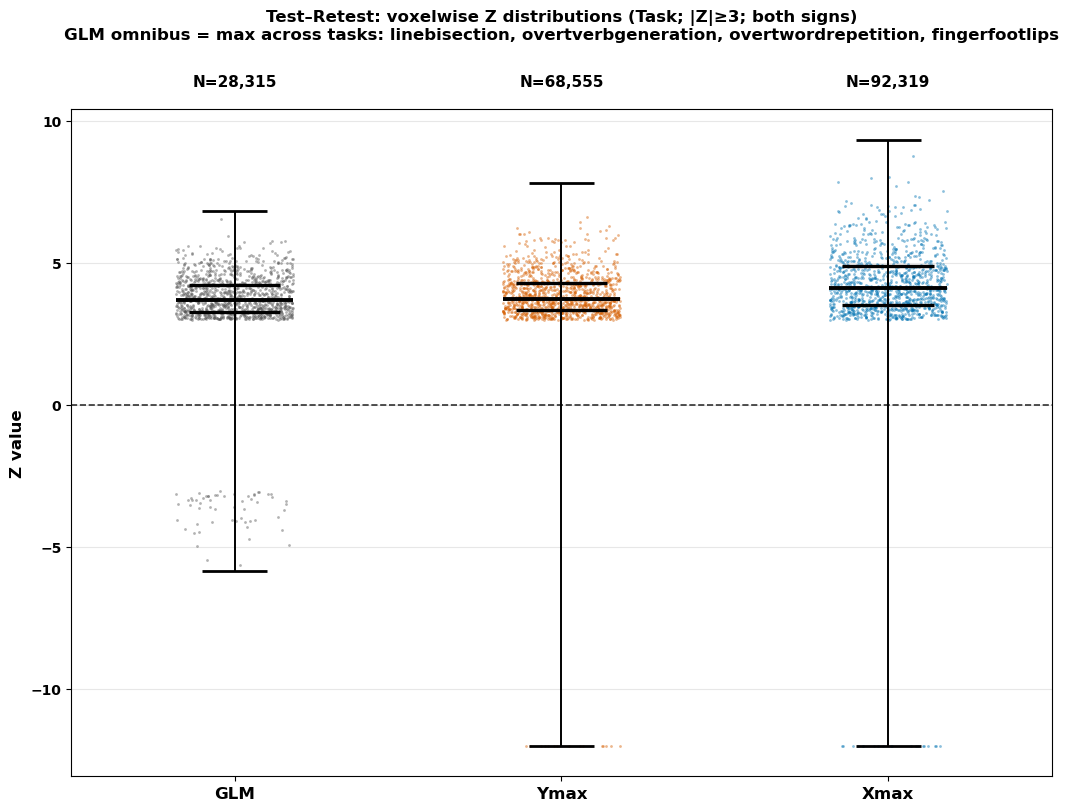

Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_swarm_fivenum_Task_GLMomnibus-max_unclipped_thr3_both.png | /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/fig_TR_swarm_fivenum_Task_GLMomnibus-max_unclipped_thr3_both.pdf
Maps used:
  GLM -> /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/GLM_omnibus_max_4tasks_zmap.nii.gz
  Ymax -> /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/Ymax_Z_Task_maxT_3D.nii.gz
  Xmax -> /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/Xmax_Zta_Task_maxT_3D.nii.gz


In [95]:
# === TEST-RETEST: Z distributions for Xmax / Ymax / GLM (Omnibus across tasks) ===
# What this does (tailored to your TR setup):
#   1) Xmax/Ymax: collapses 4D -> 3D by voxelwise max over 4th dim (UNCLIPPED)
#   2) GLM: builds a single OMNIBUS map across tasks (default: voxelwise MAX across task z-maps)
#   3) Extracts voxelwise Z values within a brain mask and plots:
#        - swarm (downsampled)
#        - five-number summary ticks (min, Q1, median, Q3, max)
#        - N label above each method
#
# Notes:
#   - Thresholding is optional: THRESH_Z applies to |Z| after masking.
#   - This plots positive & negative Z (keep vmin/vmax unbounded).
#   - If you want only positive activations, set KEEP_SIGN="pos".

import os
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from nilearn import image, masking

# ---------------- Paths (TEST-RETEST) ----------------
ROOT     = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI"
OUT_BASE = f"{ROOT}/outputs_tr"
OUT      = f"{ROOT}/results_final_TR"
Path(OUT).mkdir(parents=True, exist_ok=True)

X_DIR   = f"{OUT_BASE}/Xmax"
Y_DIR   = f"{OUT_BASE}/Ymax"
GLM_DIR = f"{OUT_BASE}/GLM_maps/second_level"

# Anatomical template (used only to compute mask if PREF_MASK missing)
anat_path = (
    f"{ROOT}/fmriprep_output/sub-01/anat/"
    "sub-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz"
)

# Preferred mask (if you have one). If missing -> compute from anat.
PREF_MASK = f"{OUT}/brain_mask.nii.gz"

# ---------------- Settings ----------------
EFFECT     = "Task"     # "Task" | "Session" | "TaskxSession" for Xmax/Ymax
GLM_TASKS  = ["linebisection", "overtverbgeneration", "overtwordrepetition", "fingerfootlips"]  # add "fingerfootlips" if you have it
GLM_MODE   = "max"      # "max" or "stouffer"
THRESH_Z   = 3.0        # include voxels with |Z| >= THRESH_Z (set 0 to include all)
KEEP_SIGN  = "both"     # "both" | "pos" | "neg"
SWARM_MAX  = 1200       # max dots per method for readability
RNG        = np.random.default_rng(7)

METHODS = ["GLM", "Ymax", "Xmax"]
COLORS  = {"GLM":"#555555", "Ymax":"#D55E00", "Xmax": "#0072B2"}  # gray, orange, blue

plt.rcParams["figure.facecolor"] = "white"

# ---------------- Helpers ----------------
def first_existing(*paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

def collapse_maxT_unclipped(in4, out3):
    """Collapse 4D → 3D via nanmax across time; no clipping."""
    if in4 is None:
        return None
    if os.path.exists(out3):
        return out3
    img4 = image.load_img(in4)
    dat  = img4.get_fdata()
    dat[~np.isfinite(dat)] = np.nan
    maxT = np.nanmax(dat, axis=3)
    nib.save(nib.Nifti1Image(maxT.astype("float32"), img4.affine, img4.header), out3)
    print("[collapse] wrote", out3)
    return out3

def load_or_make_mask(ref_img):
    """Prefer PREF_MASK; else compute from anat; resample to ref_img."""
    if os.path.exists(PREF_MASK):
        m = image.load_img(PREF_MASK)
    else:
        t1 = image.load_img(anat_path)
        m  = masking.compute_brain_mask(t1)
        outm = f"{OUT}/brain_mask_from_T1.nii.gz"
        nib.save(m, outm)
        print("[mask] wrote", outm)

    if m.shape != ref_img.shape:
        m = image.resample_to_img(m, ref_img, interpolation="nearest")
    return (m.get_fdata() > 0)

def jitter_x(x0, n, width=0.18):
    return x0 + (RNG.random(n) - 0.5) * 2 * width

# ---------------- GLM omnibus builder ----------------
def pick_glm_task_map(task):
    base = f"{GLM_DIR}/{task}"
    return first_existing(
        f"{base}/GROUP_task-{task}_TaskVsRest_zmap.nii.gz",
        f"{base}/GROUP_task-{task}_TaskVsRest_zmap_thresh.nii.gz",
    )

def build_glm_omnibus(tasks, out_path, mode="max"):
    """Build a single GLM omnibus z-map from task z-maps."""
    task_paths = []
    missing = []
    for t in tasks:
        p = pick_glm_task_map(t)
        if p:
            task_paths.append(p)
        else:
            missing.append(t)

    if missing:
        print("[WARN] Missing GLM task z-maps for:", missing)

    if len(task_paths) == 0:
        return None

    if os.path.exists(out_path):
        return out_path

    imgs = [image.load_img(p) for p in task_paths]
    ref  = imgs[0]
    imgs = [image.resample_to_img(im, ref, interpolation="continuous") for im in imgs]

    data = np.stack([im.get_fdata() for im in imgs], axis=0)
    data[~np.isfinite(data)] = np.nan

    if mode == "max":
        out = np.nanmax(data, axis=0)
    elif mode == "stouffer":
        k = data.shape[0]
        out = np.nansum(data, axis=0) / np.sqrt(k)
    else:
        raise ValueError("GLM_MODE must be 'max' or 'stouffer'")

    nib.save(nib.Nifti1Image(out.astype("float32"), ref.affine, ref.header), out_path)
    print("[glm omnibus] wrote", out_path)
    return out_path

# ---------------- Ensure method maps (3D) ----------------
def ensure_3d(effect, method):
    """
    Return a 3D Z map path for the given method/effect.
    X/Y: collapse from your 4D files (unclipped).
    GLM: build omnibus across tasks.
    """
    if method == "GLM":
        out = f"{OUT}/GLM_omnibus_{GLM_MODE}_{len(GLM_TASKS)}tasks_zmap.nii.gz"
        return build_glm_omnibus(GLM_TASKS, out_path=out, mode=GLM_MODE)

    if method == "Ymax":
        # prefer any existing 3D you may have saved
        p3 = first_existing(
            f"{OUT}/Ymax_Z_{effect}_maxT_3D.nii.gz",
            f"{Y_DIR}/Z_{effect}_maxT_3D_masked.nii.gz",
            f"{Y_DIR}/Z_{effect}_peakT_3D_clean.nii.gz",
        )
        if p3:
            return p3
        p4 = first_existing(f"{Y_DIR}/Z_{effect}_4D.nii.gz", f"{Y_DIR}/Z_{effect}_4D_capped.nii.gz")
        return collapse_maxT_unclipped(p4, f"{OUT}/Ymax_Z_{effect}_maxT_3D.nii.gz")

    if method == "Xmax":
        p3 = first_existing(
            f"{OUT}/Xmax_Zta_{effect}_maxT_3D.nii.gz",
            f"{X_DIR}/Zta_{effect}_maxT_3D_masked.nii.gz",
            f"{X_DIR}/Zta_{effect}_peakT_3D_clean.nii.gz",
        )
        if p3:
            return p3
        p4 = first_existing(f"{X_DIR}/Zta_{effect}_4D.nii.gz", f"{X_DIR}/Zta_{effect}_4D_capped.nii.gz")
        return collapse_maxT_unclipped(p4, f"{OUT}/Xmax_Zta_{effect}_maxT_3D.nii.gz")

    return None

# ---------------- Gather voxel Z values ----------------
paths = {m: ensure_3d(EFFECT, m) for m in METHODS}
ref_path = next((p for p in paths.values() if p), None)
if ref_path is None:
    raise FileNotFoundError("No maps found. Check your paths and EFFECT/GLM_TASKS.")

ref_img = image.load_img(ref_path)
brain   = load_or_make_mask(ref_img)

vals = {}
for m in METHODS:
    p = paths[m]
    if not p:
        vals[m] = np.array([], dtype="float32")
        continue

    img = image.load_img(p)
    if img.shape != ref_img.shape:
        img = image.resample_to_img(img, ref_img, interpolation="linear")

    A = img.get_fdata()
    A[~np.isfinite(A)] = np.nan
    v = A[brain]
    v = v[np.isfinite(v)]

    if KEEP_SIGN == "pos":
        v = v[v > 0]
    elif KEEP_SIGN == "neg":
        v = v[v < 0]

    if THRESH_Z > 0:
        v = v[np.abs(v) >= THRESH_Z]

    vals[m] = v.astype("float32")

# y-limits from data + pad
finite_all = np.concatenate([vals[m] for m in METHODS if len(vals[m]) > 0])
if finite_all.size == 0:
    raise ValueError("No voxels survived masking/thresholding. Lower THRESH_Z or check mask alignment.")

ymin, ymax = float(np.min(finite_all)), float(np.max(finite_all))
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
ylim = (ymin - pad, ymax + pad)

# ---------------- Plot: swarm + five-number summary ticks (no box) ----------------
fig, ax = plt.subplots(figsize=(10.5, 8), constrained_layout=True)

for i, m in enumerate(METHODS, start=1):
    v = vals[m]
    if len(v) == 0:
        ax.text(i, 0, "no data", ha="center", va="center", fontsize=10, color="#00B39F")
        continue

    # swarm (downsample for readability)
    draw = v if len(v) <= SWARM_MAX else RNG.choice(v, size=SWARM_MAX, replace=False)
    ax.plot(
        jitter_x(i, len(draw)),
        draw,
        "o",
        ms=2.0,
        alpha=0.45,
        color=COLORS[m],
        markeredgewidth=0
    )

    # five-number summary
    q0 = np.min(v); q1 = np.percentile(v, 25); q2 = np.percentile(v, 50)
    q3 = np.percentile(v, 75); q4 = np.max(v)

    ax.vlines(i, q0, q4, colors="black", lw=1.4)
    for val, lw, w in [(q0, 2.0, 0.10), (q1, 2.4, 0.14), (q2, 2.8, 0.18),
                       (q3, 2.4, 0.14), (q4, 2.0, 0.10)]:
        ax.hlines(val, i-w, i+w, colors="black", lw=lw)

    # N label above each method (correct indentation + transform)
    trans = mtransforms.BlendedGenericTransform(ax.transData, ax.transAxes)
    ax.text(
        i, 1.03, f"N={len(v):,}",
        transform=trans,
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
        clip_on=False
    )

# zero reference
ax.axhline(0, ls="--", lw=1.2, color="k", alpha=0.8)

# cosmetics
ax.set_xlim(0.5, len(METHODS) + 0.5)
ax.set_ylim(*ylim)
ax.set_xticks(range(1, len(METHODS)+1))
ax.set_xticklabels(METHODS, fontsize=12, fontweight="bold")
ax.set_ylabel("Z value", fontsize=12, fontweight="bold")

thr_txt = f"|Z|≥{THRESH_Z:g}" if THRESH_Z > 0 else "all voxels"
sign_txt = {"both":"both signs", "pos":"positive only", "neg":"negative only"}[KEEP_SIGN]

ax.set_title(
    f"Test–Retest: voxelwise Z distributions ({EFFECT}; {thr_txt}; {sign_txt})\n"
    f"GLM omnibus = {GLM_MODE} across tasks: {', '.join(GLM_TASKS)}",
    fontsize=12, fontweight="bold", pad=50
)

ax.grid(axis="y", alpha=0.3)

out_png = f"{OUT}/fig_TR_swarm_fivenum_{EFFECT}_GLMomnibus-{GLM_MODE}_unclipped_thr{THRESH_Z:g}_{KEEP_SIGN}.png"
out_pdf = f"{OUT}/fig_TR_swarm_fivenum_{EFFECT}_GLMomnibus-{GLM_MODE}_unclipped_thr{THRESH_Z:g}_{KEEP_SIGN}.pdf"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_png, "|", out_pdf)
print("Maps used:")
for k, v in paths.items():
    print(" ", k, "->", v)


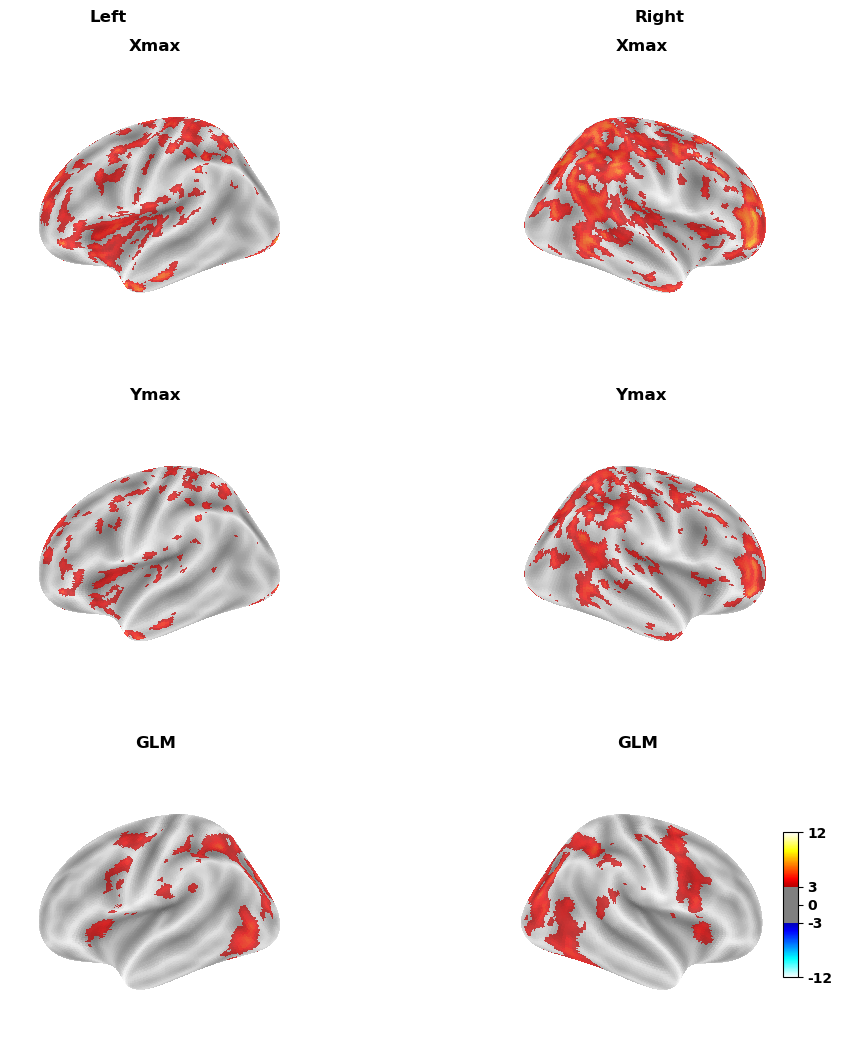

Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/surf_render_TR_Task_Xmax_Ymax_GLMomnibus-max.png | /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/surf_render_TR_Task_Xmax_Ymax_GLMomnibus-max.pdf
Maps used:
  Xmax: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/Xmax_Zta_Task_maxT_3D.nii.gz
  Ymax: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/Ymax_Z_Task_maxT_3D.nii.gz
  GLM: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/GLM_omnibus_max_4tasks_zmap.nii.gz


In [21]:
# === TEST-RETEST: Composite surface render (Xmax row1, Ymax row2, GLM-Omnibus row3) ===
import os
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import image, surface, datasets, plotting

# ---------------- Paths / knobs (TEST-RETEST) ----------------
ROOT     = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI"
OUT_BASE = f"{ROOT}/outputs_tr"
OUTDIR   = f"{ROOT}/results_final_TR"
Path(OUTDIR).mkdir(parents=True, exist_ok=True)

X_DIR   = f"{OUT_BASE}/Xmax"
Y_DIR   = f"{OUT_BASE}/Ymax"
GLM_DIR = f"{OUT_BASE}/GLM_maps/second_level"

EFFECT = "Task"   # "Task" | "Session" | "TaskxSession" for X/Y

# GLM omnibus tasks (edit to what you actually have)
GLM_TASKS = ["linebisection", "overtverbgeneration", "overtwordrepetition", "fingerfootlips"] 
GLM_MODE  = "max"       # "max" or "stouffer"

# Surface visualization settings
THR  = 3.0              # threshold in Z units (applied on surface)
VMAX = 12.0             # symmetric color range [-VMAX, VMAX]
CMAP = "cold_hot"       # good for +/- Z maps

# Optional: control projection smoothing/coverage
RADIUS    = 3.0
N_SAMPLES = 7

# ---------------- Helpers ----------------
def first_existing(*paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

def collapse_maxT_unclipped(in4, out3):
    """4D → 3D via nanmax across 4th dimension (no clipping)."""
    if in4 is None:
        return None
    if os.path.exists(out3):
        return out3
    img4 = image.load_img(in4)
    dat  = img4.get_fdata()
    dat[~np.isfinite(dat)] = np.nan
    maxT = np.nanmax(dat, axis=3)
    nib.save(nib.Nifti1Image(maxT.astype("float32"), img4.affine, img4.header), out3)
    print("[collapse] wrote", out3)
    return out3

def ensure_3d_XY(effect, method):
    """Return a 3D Z map for Xmax or Ymax; collapse 4D if needed."""
    if method == "Ymax":
        p3 = first_existing(
            f"{OUTDIR}/Ymax_Z_{effect}_maxT_3D.nii.gz",
            f"{Y_DIR}/Z_{effect}_maxT_3D_masked.nii.gz",
            f"{Y_DIR}/Z_{effect}_peakT_3D_clean.nii.gz",
        )
        if p3: return p3
        p4 = first_existing(f"{Y_DIR}/Z_{effect}_4D.nii.gz", f"{Y_DIR}/Z_{effect}_4D_capped.nii.gz")
        return collapse_maxT_unclipped(p4, f"{OUTDIR}/Ymax_Z_{effect}_maxT_3D.nii.gz")

    if method == "Xmax":
        p3 = first_existing(
            f"{OUTDIR}/Xmax_Zta_{effect}_maxT_3D.nii.gz",
            f"{X_DIR}/Zta_{effect}_maxT_3D_masked.nii.gz",
            f"{X_DIR}/Zta_{effect}_peakT_3D_clean.nii.gz",
        )
        if p3: return p3
        p4 = first_existing(f"{X_DIR}/Zta_{effect}_4D.nii.gz", f"{X_DIR}/Zta_{effect}_4D_capped.nii.gz")
        return collapse_maxT_unclipped(p4, f"{OUTDIR}/Xmax_Zta_{effect}_maxT_3D.nii.gz")

    return None

def pick_glm_task_map(task):
    base = f"{GLM_DIR}/{task}"
    return first_existing(
        f"{base}/GROUP_task-{task}_TaskVsRest_zmap.nii.gz",
        f"{base}/GROUP_task-{task}_TaskVsRest_zmap_thresh.nii.gz",
    )

def build_glm_omnibus(tasks, out_path, mode="max"):
    """Build a single GLM omnibus z-map from multiple task z-maps."""
    task_paths, missing = [], []
    for t in tasks:
        p = pick_glm_task_map(t)
        (task_paths if p else missing).append(p or t)

    if missing:
        print("[WARN] Missing GLM task maps for:", [x for x in missing if isinstance(x, str)])

    task_paths = [p for p in task_paths if isinstance(p, str)]
    if len(task_paths) == 0:
        return None

    if os.path.exists(out_path):
        return out_path

    imgs = [image.load_img(p) for p in task_paths]
    ref  = imgs[0]
    imgs = [image.resample_to_img(im, ref, interpolation="continuous") for im in imgs]

    data = np.stack([im.get_fdata() for im in imgs], axis=0)
    data[~np.isfinite(data)] = np.nan

    if mode == "max":
        out = np.nanmax(data, axis=0)
    elif mode == "stouffer":
        k = data.shape[0]
        out = np.nansum(data, axis=0) / np.sqrt(k)
    else:
        raise ValueError("mode must be 'max' or 'stouffer'")

    nib.save(nib.Nifti1Image(out.astype("float32"), ref.affine, ref.header), out_path)
    print("[glm omnibus] wrote", out_path)
    return out_path

def vol_to_surf_pair(z_img, fsavg):
    """Project a volume to left/right surfaces."""
    tex_l = surface.vol_to_surf(
        z_img, fsavg.pial_left, radius=RADIUS, n_samples=N_SAMPLES, interpolation="linear"
    )
    tex_r = surface.vol_to_surf(
        z_img, fsavg.pial_right, radius=RADIUS, n_samples=N_SAMPLES, interpolation="linear"
    )
    return tex_l, tex_r

# ---------------- Fetch fsaverage surfaces ----------------
# (This may download once if not cached)
fsavg = datasets.fetch_surf_fsaverage(mesh="fsaverage5")

# ---------------- Collect/prepare maps ----------------
x3 = ensure_3d_XY(EFFECT, "Xmax")
y3 = ensure_3d_XY(EFFECT, "Ymax")
g3 = build_glm_omnibus(GLM_TASKS, out_path=f"{OUTDIR}/GLM_omnibus_{GLM_MODE}_{len(GLM_TASKS)}tasks_zmap.nii.gz", mode=GLM_MODE)

assert x3 is not None, f"Missing Xmax map for {EFFECT}"
assert y3 is not None, f"Missing Ymax map for {EFFECT}"
assert g3 is not None, f"Missing GLM omnibus map (check GLM_TASKS folders)"

order = [("Xmax", x3), ("Ymax", y3), ("GLM", g3)]

# Load + project
surf_data = {}
for name, p in order:
    z_img = image.load_img(p)
    surf_data[name] = vol_to_surf_pair(z_img, fsavg)

# ---------------- Figure: 3 rows × 2 cols ----------------
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.weight"] = "bold"

fig = plt.figure(figsize=(11.5, 12.5))
gs  = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1, 1, 1])

# Header spacing
fig.subplots_adjust(top=0.90)
#fig.suptitle(f"{EFFECT} — Surface projection (TR) | GLM omnibus = {GLM_MODE} across tasks", fontsize=15, fontweight="bold", y=0.975)

# Column headers
fig.text(0.26, 0.93, "Left",  ha="center", va="bottom", fontsize=12, fontweight="bold")
fig.text(0.74, 0.93, "Right", ha="center", va="bottom", fontsize=12, fontweight="bold")

def plot_row(row_idx, name, show_cbar=False):
    tex_l, tex_r = surf_data[name]

    # Left hemi
    axL = fig.add_subplot(gs[row_idx, 0], projection="3d")
    plotting.plot_surf_stat_map(
        surf_mesh=fsavg.infl_left, stat_map=tex_l,
        hemi="left", view="lateral",
        bg_map=fsavg.sulc_left, bg_on_data=True, darkness=0.6,
        cmap=CMAP, vmin=-VMAX, vmax=VMAX, threshold=THR,
        symmetric_cbar=True, colorbar=False, axes=axL
    )
    axL.set_title(f"{name}", fontsize=12, fontweight="bold", pad=8)
    axL.set_axis_off()

    # Right hemi
    axR = fig.add_subplot(gs[row_idx, 1], projection="3d")
    plotting.plot_surf_stat_map(
        surf_mesh=fsavg.infl_right, stat_map=tex_r,
        hemi="right", view="lateral",
        bg_map=fsavg.sulc_right, bg_on_data=True, darkness=0.6,
        cmap=CMAP, vmin=-VMAX, vmax=VMAX, threshold=THR,
        symmetric_cbar=True, colorbar=show_cbar, axes=axR
    )
    axR.set_title(f"{name}", fontsize=12, fontweight="bold", pad=8)
    axR.set_axis_off()

# Rows (put colorbar only on last row to avoid clutter)
plot_row(0, "Xmax", show_cbar=False)
plot_row(1, "Ymax", show_cbar=False)
plot_row(2, "GLM",  show_cbar=True)

out_png = os.path.join(OUTDIR, f"surf_render_TR_{EFFECT}_Xmax_Ymax_GLMomnibus-{GLM_MODE}.png")
out_pdf = os.path.join(OUTDIR, f"surf_render_TR_{EFFECT}_Xmax_Ymax_GLMomnibus-{GLM_MODE}.pdf")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_png, "|", out_pdf)
print("Maps used:")
for n, p in order:
    print(f"  {n}: {p}")


/var/folders/vc/8q1m7m693f9ct6h61j_ft6tm0000gn/T/ipykernel_12287/3737751941.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)


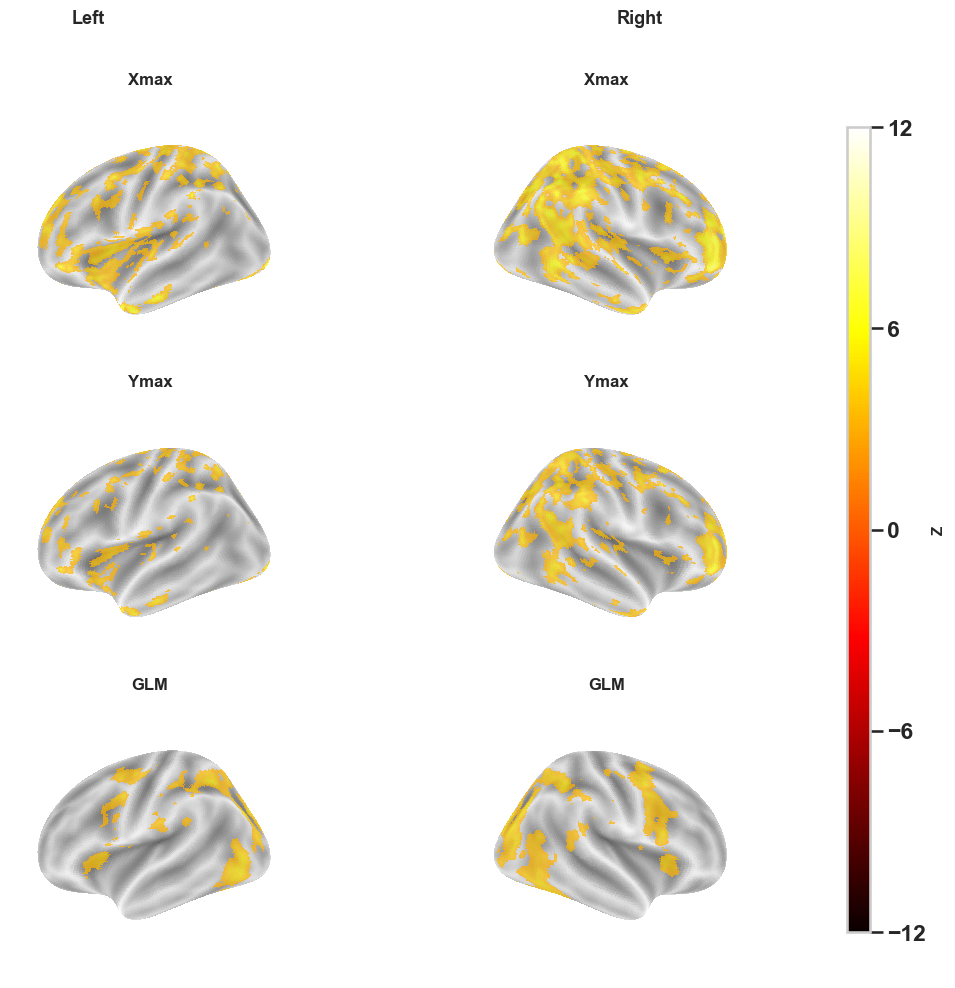

Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/surf_render_TR_Task_FINAL.png | /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR/surf_render_TR_Task_FINAL.pdf


In [67]:
# ================================
# FIGURE (FINAL REFINED)
#   ✔ tighter vertical spacing
#   ✔ ONE tall colorbar spanning all rows
# ================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.weight"] = "bold"

fig = plt.figure(figsize=(11.5, 11.5))

# 🔥 tighter vertical spacing
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    height_ratios=[1, 1, 1],
    hspace=0.08,   # 🔥 reduced vertical gap
    wspace=0.05
)

# Column headers
fig.text(0.26, 0.94, "Left",  ha="center", fontsize=13, fontweight="bold")
fig.text(0.74, 0.94, "Right", ha="center", fontsize=13, fontweight="bold")

# ---------------- Plot rows ----------------
def plot_row(row_idx, name):
    tex_l, tex_r = surf_data[name]

    # LEFT
    axL = fig.add_subplot(gs[row_idx, 0], projection="3d")
    plotting.plot_surf_stat_map(
        surf_mesh=fsavg.infl_left,
        stat_map=tex_l,
        hemi="left", view="lateral",
        bg_map=fsavg.sulc_left,
        bg_on_data=True, darkness=0.6,
        cmap=CMAP,
        vmin=-VMAX, vmax=VMAX,
        threshold=THR,
        symmetric_cbar=True,
        colorbar=False,
        axes=axL
    )
    axL.set_title(name, fontsize=12, fontweight="bold", pad=6)
    axL.set_axis_off()

    # RIGHT
    axR = fig.add_subplot(gs[row_idx, 1], projection="3d")
    plotting.plot_surf_stat_map(
        surf_mesh=fsavg.infl_right,
        stat_map=tex_r,
        hemi="right", view="lateral",
        bg_map=fsavg.sulc_right,
        bg_on_data=True, darkness=0.6,
        cmap=CMAP,
        vmin=-VMAX, vmax=VMAX,
        threshold=THR,
        symmetric_cbar=True,
        colorbar=False,   # 🔥 remove individual colorbars
        axes=axR
    )
    axR.set_title(name, fontsize=12, fontweight="bold", pad=6)
    axR.set_axis_off()

# Draw rows
plot_row(0, "Xmax")
plot_row(1, "Ymax")
plot_row(2, "GLM")

# ---------------- GLOBAL COLORBAR ----------------
norm = mpl.colors.Normalize(vmin=-VMAX, vmax=VMAX)
sm = mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap(CMAP), norm=norm)
sm.set_array([])

# 🔥 manually place tall colorbar spanning figure height
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.70])  
# [left, bottom, width, height]

cbar = fig.colorbar(sm, cax=cbar_ax)

cbar.set_ticks([-12, -6, 0, 6, 12])
cbar.set_label("Z", fontsize=11, fontweight="bold")

for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")

# ---------------- SAVE ----------------
out_png = os.path.join(OUTDIR, f"surf_render_TR_{EFFECT}_FINAL.png")
out_pdf = os.path.join(OUTDIR, f"surf_render_TR_{EFFECT}_FINAL.pdf")

fig.savefig(out_png, dpi=600, bbox_inches="tight")
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")

plt.show()

print("Saved:", out_png, "|", out_pdf)

In [33]:
# ================= TOP PEAK EXTRACTION (ROBUST VERSION) =================

from nilearn.image import load_img
from nilearn.reporting import get_clusters_table
import pandas as pd
import numpy as np
from scipy.stats import norm

# ---------------- SETTINGS ----------------
TOP_N     = 20
THRESH_Z  = 3.0
MIN_DIST  = 8   # mm separation between peaks

# ---------------- MAPS ----------------
maps = {
    "GLM": g3,
    "Ymax": y3,
    "Xmax": x3
}

all_results = []

# ---------------- LOOP THROUGH METHODS ----------------
for method, path in maps.items():

    print(f"\nProcessing: {method}")

    img = load_img(path)

    table = get_clusters_table(
        img,
        stat_threshold=THRESH_Z,
        cluster_threshold=0,
        min_distance=MIN_DIST
    )

    if table is None or len(table) == 0:
        print(f"No peaks found for {method}")
        continue

    # ---------------- STANDARDIZE COLUMN NAMES ----------------
    table.columns = [c.strip().lower().replace(" ", "_") for c in table.columns]

    # Identify stat column automatically
    stat_col = None
    for c in table.columns:
        if "stat" in c:
            stat_col = c
            break

    if stat_col is None:
        raise ValueError(f"Could not find stat column in {table.columns}")

    # ---------------- SORT + SELECT TOP N ----------------
    table = table.sort_values(by=stat_col, ascending=False).head(TOP_N).copy()

    # ---------------- RENAME COLUMNS ----------------
    table = table.rename(columns={
        stat_col: "Z",
        "x": "x",
        "y": "y",
        "z": "z"
    })

    # ---------------- ADD EXTRA FIELDS ----------------
    table["Method"] = method
    table["Cluster"] = np.arange(1, len(table) + 1)

    # Hemisphere
    table["Hemisphere"] = table["x"].apply(lambda x: "L" if x < 0 else "R")

    # P-values (two-sided normal approximation)
    table["P"] = 2 * (1 - norm.cdf(np.abs(table["Z"])))

    # ---------------- SELECT FINAL COLUMNS ----------------
    table = table[[
        "Method",
        "Cluster",
        "Hemisphere",
        "x", "y", "z",
        "Z",
        "P"
    ]]

    all_results.append(table)

# ---------------- COMBINE ALL METHODS ----------------
df_peaks = pd.concat(all_results)

# Sort nicely
df_peaks = df_peaks.sort_values(["Method", "Z"], ascending=[True, False])

# ---------------- OUTPUT ----------------
print("\nTop Peaks (Preview):")
print(df_peaks.head(20))

# Optional: save to CSV
df_peaks.to_csv(f"{OUT}/top_peaks_all_methods.csv", index=False)

print(f"\nSaved to: {OUT}/top_peaks_all_methods.csv")


Processing: GLM

Processing: Ymax

Processing: Xmax

Top Peaks (Preview):
   Method  Cluster Hemisphere     x     y     z         Z             P
0     GLM        1          R  35.5 -84.5  17.5  6.830642  8.453460e-12
1     GLM        2          L -30.5 -78.5  25.5  6.661393  2.712430e-11
4     GLM        3          L -26.5  -0.5   9.5  6.575432  4.851208e-11
2     GLM        4          R  13.5 -78.5 -10.5  6.574768  4.872902e-11
3     GLM        5          R  31.5 -74.5  29.5  6.543497  6.009659e-11
8     GLM        6          L -36.5  -4.5  49.5  6.308529  2.816993e-10
12    GLM        7          R  11.5 -16.5  11.5  6.144818  8.005534e-10
5     GLM        8          L -30.5 -20.5   1.5  5.925368  3.115982e-09
6     GLM        9          L -16.5 -20.5  13.5  5.634255  1.758163e-08
13    GLM       10          R  17.5  -4.5  17.5  5.621637  1.891560e-08
9     GLM       11          L -52.5   1.5  41.5  5.589396  2.278602e-08
14    GLM       12          R  29.5 -18.5   5.5  5.530089  3.

In [44]:
# ================= FINAL ROBUST MULTI-ATLAS LABELING =================

import numpy as np
import pandas as pd
from nilearn import datasets, image
from nilearn.image import load_img, resample_to_img
import xml.etree.ElementTree as ET
from pathlib import Path

print("\n🚀 Starting Robust Multi-Atlas Labeling...")

# ============================================================
# STEP 1 — LOAD REFERENCE IMAGE (CRITICAL FIX)
# ============================================================

# Use your GLM map as reference (ensures alignment)
ref_img = load_img(g3)

# ============================================================
# STEP 2 — HARVARD-OXFORD (RESAMPLED)
# ============================================================

print("Loading Harvard-Oxford...")

cort = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
sub  = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')

cort_img = resample_to_img(load_img(cort.maps), ref_img, interpolation="nearest")
sub_img  = resample_to_img(load_img(sub.maps),  ref_img, interpolation="nearest")

cort_data, cort_affine, cort_labels = cort_img.get_fdata(), cort_img.affine, cort.labels
sub_data,  sub_affine,  sub_labels  = sub_img.get_fdata(),  sub_img.affine,  sub.labels

HO_dict = dict(enumerate(cort_labels))

# ============================================================
# STEP 3 — AAL (RESAMPLED)
# ============================================================

print("Loading AAL...")

AAL_DIR = Path("/Users/theophilusacquah/Documents/PHD_FORMS/PHD_FORMS/Job_Applications/2025/PostDoctorate/Post-Doc-Cleveland/Projects/Project_Frequency_DBS/Atlas/AAL3")

aal_img = resample_to_img(
    load_img(str(AAL_DIR / "AAL3v1.nii.gz")),
    ref_img,
    interpolation="nearest"
)

aal_data, aal_affine = aal_img.get_fdata(), aal_img.affine

aal_df = pd.read_csv(AAL_DIR / "AAL3v1.nii.txt", sep=r"\s+", header=None, engine="python")
aal_dict = dict(zip(aal_df.iloc[:,0].astype(int), aal_df.iloc[:,1]))

# ============================================================
# STEP 4 — NEUROMORPH (RESAMPLED)
# ============================================================

print("Loading Neuromorph...")

neuro_img = resample_to_img(
    load_img("/Users/theophilusacquah/Documents/PHD_FORMS/PHD_FORMS/Job_Applications/2025/PostDoctorate/Post-Doc-Cleveland/Projects/IAPRD_2026/Atlas/Human -Neuromorphometrics Inc. manually segmented brain/1103_3_glm.nii.gz"),
    ref_img,
    interpolation="nearest"
)

neuro_data, neuro_affine = neuro_img.get_fdata(), neuro_img.affine

xml_path = "/Users/theophilusacquah/Documents/PHD_FORMS/PHD_FORMS/Job_Applications/2025/PostDoctorate/Post-Doc-Cleveland/Projects/IAPRD_2026/Atlas/Neuromorphometrics_SPM/labels_Neuromorphometrics.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

neuro_dict = {}
for label in root.iter('label'):
    if 'index' in label.attrib:
        idx = int(label.attrib['index'])
        name = label.attrib.get('name', 'Unknown')
    elif 'id' in label.attrib:
        idx = int(label.attrib['id'])
        name = label.attrib.get('fullname', label.attrib.get('name', 'Unknown'))
    else:
        continue
    neuro_dict[idx] = name

# ============================================================
# STEP 5 — ROBUST LOOKUP (CRITICAL FIX)
# ============================================================

def robust_lookup(coord, data, affine, mapping, radius=2):
    coord = np.array(coord)
    voxel = np.linalg.inv(affine).dot(np.append(coord,1))[:3]
    voxel = np.round(voxel).astype(int)

    for r in range(radius+1):
        for dx in range(-r, r+1):
            for dy in range(-r, r+1):
                for dz in range(-r, r+1):

                    v = voxel + np.array([dx, dy, dz])

                    if np.all((v >= 0) & (v < data.shape)):
                        val = int(data[tuple(v)])

                        if val > 0:
                            return mapping.get(val, f"Unknown_{val}")

    return None

# ============================================================
# STEP 6 — APPLY PRIORITY LABELING
# ============================================================

print("Mapping coordinates...")

HO_list, AAL_list, NEURO_list, FINAL_label = [], [], [], []

for _, r in df_peaks.iterrows():
    coord = [r["x"], r["y"], r["z"]]

    ho = robust_lookup(coord, cort_data, cort_affine, HO_dict)
    aal = robust_lookup(coord, aal_data, aal_affine, aal_dict)
    neuro = robust_lookup(coord, neuro_data, neuro_affine, neuro_dict)

    HO_list.append(ho)
    AAL_list.append(aal)
    NEURO_list.append(neuro)

    # Priority: HO → AAL → Neuro
    final = ho or aal or neuro or "Unlabeled"
    FINAL_label.append(final)

# Add columns
df_peaks["HO_Region"] = HO_list
df_peaks["AAL_Region"] = AAL_list
df_peaks["NeuroMorph_Region"] = NEURO_list
df_peaks["Final_Region"] = FINAL_label

# Hemisphere
df_peaks["Hemisphere"] = df_peaks["x"].apply(
    lambda x: "L" if x < 0 else "R" if x > 0 else "Midline"
)

# ============================================================
# STEP 7 — FINAL TABLE
# ============================================================

final_df = df_peaks[[
    "Method",
    "Cluster",
    "Hemisphere",
    "x", "y", "z",
    "HO_Region",
    "AAL_Region",
    "NeuroMorph_Region",
    "Final_Region",
    "Z",
    "P"
]].sort_values(["Method", "Z"], ascending=[True, False]).reset_index(drop=True)

print("\n✅ FINAL TABLE PREVIEW:")
print(final_df.head(20))

# ============================================================
# STEP 8 — SAVE OUTPUT
# ============================================================

OUT = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR"

final_df.to_csv(f"{OUT}/top_peaks_multiatlas_REFINED.csv", index=False)

print("\n🔥 DONE — REFINED MULTI-ATLAS TABLE READY")


🚀 Starting Robust Multi-Atlas Labeling...
Loading Harvard-Oxford...
Loading AAL...
Loading Neuromorph...
Mapping coordinates...

✅ FINAL TABLE PREVIEW:
   Method  Cluster Hemisphere     x     y     z  \
0     GLM        1          R  35.5 -84.5  17.5   
1     GLM        2          L -30.5 -78.5  25.5   
2     GLM        3          L -26.5  -0.5   9.5   
3     GLM        4          R  13.5 -78.5 -10.5   
4     GLM        5          R  31.5 -74.5  29.5   
5     GLM        6          L -36.5  -4.5  49.5   
6     GLM        7          R  11.5 -16.5  11.5   
7     GLM        8          L -30.5 -20.5   1.5   
8     GLM        9          L -16.5 -20.5  13.5   
9     GLM       10          R  17.5  -4.5  17.5   
10    GLM       11          L -52.5   1.5  41.5   
11    GLM       12          R  29.5 -18.5   5.5   
12    GLM       13          R   5.5  13.5  53.5   
13    GLM       14          R  29.5 -12.5  13.5   
14    GLM       15          L  -6.5  -2.5  67.5   
15    GLM       16          L -

In [46]:
# ================= ULTRA-ROBUST MULTI-ATLAS LABELING =================

import numpy as np
import pandas as pd
from nilearn import datasets
from nilearn.image import load_img, resample_to_img
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

print("\n🚀 Starting ULTRA-ROBUST Atlas Labeling...")

# ============================================================
# STEP 1 — REFERENCE IMAGE (ALIGN EVERYTHING)
# ============================================================

ref_img = load_img(g3)  # your GLM map

# ============================================================
# STEP 2 — LOAD & RESAMPLE ATLASES
# ============================================================

# -------- Harvard-Oxford --------
cort = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
sub  = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')

cort_img = resample_to_img(load_img(cort.maps), ref_img, interpolation="nearest")
sub_img  = resample_to_img(load_img(sub.maps),  ref_img, interpolation="nearest")

cort_data, cort_affine, cort_labels = cort_img.get_fdata(), cort_img.affine, cort.labels
sub_data,  sub_affine,  sub_labels  = sub_img.get_fdata(),  sub_img.affine,  sub.labels

HO_dict = dict(enumerate(cort_labels))

# -------- AAL --------
AAL_DIR = Path("/Users/theophilusacquah/Documents/PHD_FORMS/PHD_FORMS/Job_Applications/2025/PostDoctorate/Post-Doc-Cleveland/Projects/Project_Frequency_DBS/Atlas/AAL3")

aal_img = resample_to_img(
    load_img(str(AAL_DIR / "AAL3v1.nii.gz")),
    ref_img,
    interpolation="nearest"
)

aal_data, aal_affine = aal_img.get_fdata(), aal_img.affine

aal_df = pd.read_csv(AAL_DIR / "AAL3v1.nii.txt", sep=r"\s+", header=None, engine="python")
aal_dict = dict(zip(aal_df.iloc[:,0].astype(int), aal_df.iloc[:,1]))

# -------- Neuromorph --------
neuro_img = resample_to_img(
    load_img("/Users/theophilusacquah/Documents/PHD_FORMS/PHD_FORMS/Job_Applications/2025/PostDoctorate/Post-Doc-Cleveland/Projects/IAPRD_2026/Atlas/Human -Neuromorphometrics Inc. manually segmented brain/1103_3_glm.nii.gz"),
    ref_img,
    interpolation="nearest"
)

neuro_data, neuro_affine = neuro_img.get_fdata(), neuro_img.affine

xml_path = "/Users/theophilusacquah/Documents/PHD_FORMS/PHD_FORMS/Job_Applications/2025/PostDoctorate/Post-Doc-Cleveland/Projects/IAPRD_2026/Atlas/Neuromorphometrics_SPM/labels_Neuromorphometrics.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

neuro_dict = {}
for label in root.iter('label'):
    if 'index' in label.attrib:
        idx = int(label.attrib['index'])
        name = label.attrib.get('name', 'Unknown')
    elif 'id' in label.attrib:
        idx = int(label.attrib['id'])
        name = label.attrib.get('fullname', label.attrib.get('name', 'Unknown'))
    else:
        continue
    neuro_dict[idx] = name

# ============================================================
# STEP 3 — ADVANCED LOOKUP (MAJORITY VOTING)
# ============================================================

def advanced_lookup(coord, data, affine, mapping, max_radius=3):

    coord = np.array(coord)
    voxel = np.linalg.inv(affine).dot(np.append(coord,1))[:3]
    voxel = np.round(voxel).astype(int)

    candidates = []

    for radius in range(1, max_radius + 1):

        for dx in range(-radius, radius+1):
            for dy in range(-radius, radius+1):
                for dz in range(-radius, radius+1):

                    v = voxel + np.array([dx, dy, dz])

                    if np.all((v >= 0) & (v < data.shape)):
                        val = int(data[tuple(v)])

                        if val > 0:
                            label = mapping.get(val, f"Unknown_{val}")

                            # distance weight (closer voxels count more)
                            dist = np.sqrt(dx**2 + dy**2 + dz**2)
                            weight = 1 / (1 + dist)

                            candidates.append((label, weight))

        if candidates:
            break  # stop early if found something

    if not candidates:
        return None

    # Weighted voting
    score = {}
    for label, weight in candidates:
        score[label] = score.get(label, 0) + weight

    return max(score, key=score.get)

# ============================================================
# STEP 4 — APPLY MULTI-ATLAS + PRIORITY
# ============================================================

HO_list, AAL_list, NEURO_list, FINAL = [], [], [], []

print("Mapping coordinates with advanced lookup...")

for _, r in df_peaks.iterrows():

    coord = [r["x"], r["y"], r["z"]]

    ho = advanced_lookup(coord, cort_data, cort_affine, HO_dict)
    aal = advanced_lookup(coord, aal_data, aal_affine, aal_dict)
    neuro = advanced_lookup(coord, neuro_data, neuro_affine, neuro_dict)

    HO_list.append(ho)
    AAL_list.append(aal)
    NEURO_list.append(neuro)

    # Priority system
    final = ho or aal or neuro or "Unlabeled"
    FINAL.append(final)

# Add columns
df_peaks["HO_Region"] = HO_list
df_peaks["AAL_Region"] = AAL_list
df_peaks["NeuroMorph_Region"] = NEURO_list
df_peaks["Final_Region"] = FINAL

# Hemisphere
df_peaks["Hemisphere"] = df_peaks["x"].apply(
    lambda x: "L" if x < 0 else "R" if x > 0 else "Midline"
)

# ============================================================
# STEP 5 — FINAL TABLE
# ============================================================

final_df = df_peaks[[
    "Method",
    "Cluster",
    "Hemisphere",
    "x", "y", "z",
    "HO_Region",
    "AAL_Region",
    "NeuroMorph_Region",
    "Final_Region",
    "Z",
    "P"
]].sort_values(["Method", "Z"], ascending=[True, False]).reset_index(drop=True)

print("\n🔥 FINAL TABLE (PREVIEW):")
print(final_df.head(20))

# ============================================================
# STEP 6 — SAVE
# ============================================================

OUT = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/results_final_TR"

final_df.to_csv(f"{OUT}/top_peaks_multiatlas_ULTRA_REFINED.csv", index=False)

print("\n✅ DONE — ULTRA ROBUST LABELING COMPLETE")


🚀 Starting ULTRA-ROBUST Atlas Labeling...
Mapping coordinates with advanced lookup...

🔥 FINAL TABLE (PREVIEW):
   Method  Cluster Hemisphere     x     y     z  \
0     GLM        1          R  35.5 -84.5  17.5   
1     GLM        2          L -30.5 -78.5  25.5   
2     GLM        3          L -26.5  -0.5   9.5   
3     GLM        4          R  13.5 -78.5 -10.5   
4     GLM        5          R  31.5 -74.5  29.5   
5     GLM        6          L -36.5  -4.5  49.5   
6     GLM        7          R  11.5 -16.5  11.5   
7     GLM        8          L -30.5 -20.5   1.5   
8     GLM        9          L -16.5 -20.5  13.5   
9     GLM       10          R  17.5  -4.5  17.5   
10    GLM       11          L -52.5   1.5  41.5   
11    GLM       12          R  29.5 -18.5   5.5   
12    GLM       13          R   5.5  13.5  53.5   
13    GLM       14          R  29.5 -12.5  13.5   
14    GLM       15          L  -6.5  -2.5  67.5   
15    GLM       16          L -14.5 -10.5  13.5   
16    GLM       17  


🔥 ROI RESULTS:
        ROI       GLM      Ymax      Xmax
0        V1  3.912882  1.182423  1.328280
1       LOC  2.221494  1.739908  2.018680
2       STG  0.533429  1.885147  2.189250
3       IFG  1.368652  1.672014  1.882341
4  TempPole  0.404681  2.143368  2.542710
5   FPC/MFG  0.602219  2.424108  2.841089
6        M1  1.059027  2.368672  2.785338
7       SMA  1.899251  2.208257  2.588897

✅ Saved to: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Results_final_tr/roi_results.csv
✅ Figure saved to: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Results_final_tr/roi_comparison_plot.png


<Figure size 1000x600 with 0 Axes>

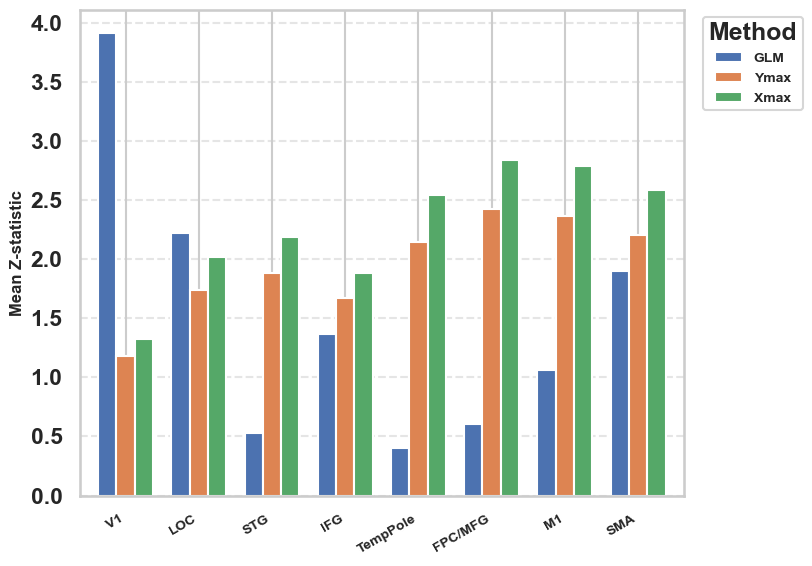

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import datasets, image, masking
from nilearn.image import load_img, resample_to_img

# ===========================
# LOAD YOUR MAPS
# ===========================
maps = {
    "GLM": g3,
    "Ymax": y3,
    "Xmax": x3
}

imgs = {k: load_img(v) for k, v in maps.items()}

glm_img  = imgs["GLM"]
ymax_img = imgs["Ymax"]
xmax_img = imgs["Xmax"]

# ===========================
# LOAD ATLAS
# ===========================
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')

atlas_img = load_img(atlas.maps)
atlas_img = resample_to_img(atlas_img, glm_img, interpolation='nearest')

atlas_data = atlas_img.get_fdata()
atlas_labels = atlas.labels

# ===========================
# ROI DEFINITIONS (FINAL SET)
# ===========================
ROI_LABELS = {
    "V1": ["Intracalcarine Cortex"],
    "LOC": ["Lateral Occipital Cortex"],
    "STG": ["Superior Temporal Gyrus"],
    "IFG": ["Inferior Frontal Gyrus"],
    "TempPole": ["Temporal Pole"],
    "FPC/MFG": ["Frontal Pole", "Middle Frontal Gyrus"],
    "M1": ["Precentral Gyrus"],
    "SMA": ["Juxtapositional Lobule Cortex"]
}

# ===========================
# OPTIONAL: ADD EXTRA ROIs (SUPPLEMENT ONLY)
# ===========================
ADD_EXTRA = False

if ADD_EXTRA:
    ROI_LABELS.update({
        "Thalamus": ["Thalamus"],
        "Caudate": ["Caudate"],
        "ITG": ["Inferior Temporal Gyrus"]
    })

# ===========================
# ROBUST ROI MASK FUNCTION
# ===========================
def get_roi_mask(label_list):
    mask = np.zeros(atlas_data.shape)

    for i, label in enumerate(atlas_labels):
        label_clean = label.lower()

        for roi in label_list:
            if roi.lower() in label_clean:
                mask[atlas_data == i] = 1

    return mask

# ===========================
# EXTRACT MEAN SIGNAL
# ===========================
results = []

for roi_name, label_list in ROI_LABELS.items():

    mask = get_roi_mask(label_list)

    if mask.sum() == 0:
        print(f"⚠️ No voxels found for {roi_name}")
        continue

    mask_img = image.new_img_like(atlas_img, mask)

    glm_val  = masking.apply_mask(glm_img, mask_img).mean()
    ymax_val = masking.apply_mask(ymax_img, mask_img).mean()
    xmax_val = masking.apply_mask(xmax_img, mask_img).mean()

    results.append({
        "ROI": roi_name,
        "GLM": glm_val,
        "Ymax": ymax_val,
        "Xmax": xmax_val
    })

# ===========================
# DATAFRAME
# ===========================
roi_df = pd.DataFrame(results)

print("\n🔥 ROI RESULTS:")
print(roi_df)

# ===========================
# SAVE
# ===========================
out_path = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Results_final_tr/roi_results.csv"
roi_df.to_csv(out_path, index=False)

print(f"\n✅ Saved to: {out_path}")

# ===========================
# 🔥 PUBLICATION-READY PLOT
# ===========================
plt.figure(figsize=(10,6))

ax = roi_df.set_index("ROI").plot(
    kind="bar",
    width=0.75,
    figsize=(10,6)
)

plt.ylabel("Mean Z-statistic", fontsize=12)
plt.xlabel("")

# CLEAN X LABELS
plt.xticks(rotation=30, ha='right', fontsize=10)

# LEGEND OUTSIDE
plt.legend(
    title="Method",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=10
)

# GRID FOR PUBLICATION LOOK
plt.grid(axis='y', linestyle='--', alpha=0.5)

# TIGHT LAYOUT (SPACE FOR LEGEND)
plt.tight_layout(rect=[0, 0, 0.85, 1])


# ===========================
# SAVE FIGURE (PNG ONLY - FIXED)
# ===========================
fig_path = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Results_final_tr/roi_comparison_plot.png"

# SAVE BEFORE SHOW
plt.savefig(
    fig_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

print(f"✅ Figure saved to: {fig_path}")

# THEN DISPLAY
plt.show()

In [89]:
import os
import numpy as np
from nilearn import datasets, image
from nilearn.image import load_img

# ===========================
# OUTPUT DIRECTORY
# ===========================
ROI_DIR = "/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs"
os.makedirs(ROI_DIR, exist_ok=True)

# ===========================
# LOAD ATLAS
# ===========================
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')

atlas_img = load_img(atlas.maps)
atlas_data = atlas_img.get_fdata()
labels = atlas.labels

# ===========================
# YOUR 8 ROIs
# ===========================
ROI_TARGETS = {
    "Intracalcarine_Cortex": ["Intracalcarine Cortex"],
    "Lateral_Occipital_Cortex": ["Lateral Occipital Cortex"],
    "Superior_Temporal_Gyrus": ["Superior Temporal Gyrus"],
    "Inferior_Frontal_Gyrus": ["Inferior Frontal Gyrus"],
    "Temporal_Pole": ["Temporal Pole"],
    "Frontal_Pole": ["Frontal Pole", "Middle Frontal Gyrus"],
    "Precentral_Gyrus": ["Precentral Gyrus"],
    "SMA": ["Juxtapositional Lobule Cortex"]
}

# ===========================
# CREATE ROI MASKS
# ===========================
for roi_name, keywords in ROI_TARGETS.items():

    mask = np.zeros(atlas_data.shape)

    for i, label in enumerate(labels):
        label_lower = label.lower()

        for key in keywords:
            if key.lower() in label_lower:
                mask[atlas_data == i] = 1

    if mask.sum() == 0:
        print(f"⚠️ No voxels found for {roi_name}")
        continue

    roi_img = image.new_img_like(atlas_img, mask)

    out_path = os.path.join(ROI_DIR, f"ROI_{roi_name}.nii.gz")
    roi_img.to_filename(out_path)

    print(f"✅ Saved: {out_path}")

✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs/ROI_Intracalcarine_Cortex.nii.gz
✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs/ROI_Lateral_Occipital_Cortex.nii.gz
✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs/ROI_Superior_Temporal_Gyrus.nii.gz
✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs/ROI_Inferior_Frontal_Gyrus.nii.gz
✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs/ROI_Temporal_Pole.nii.gz
✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs/ROI_Frontal_Pole.nii.gz
✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs/ROI_Precentral_Gyrus.nii.gz
✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_

✅ Saved: /Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Results_final_tr/roi_figs/ROI_overlay_GLMymaxXmax.png


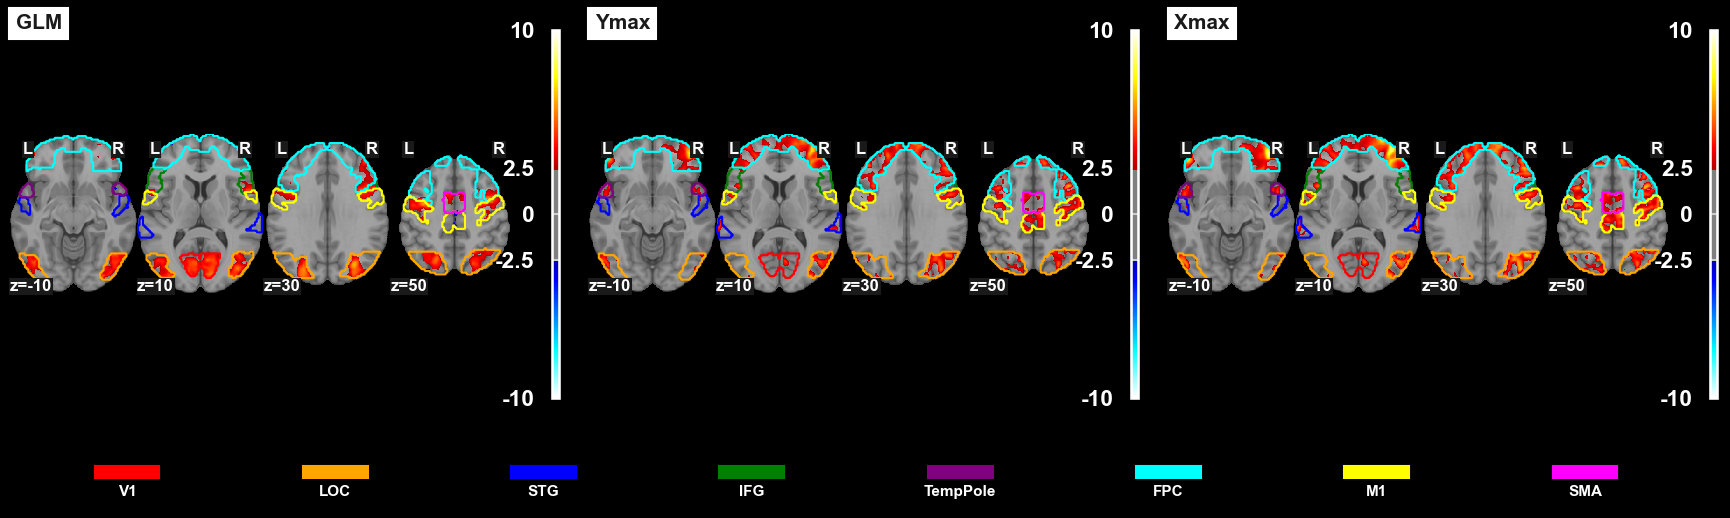

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from nilearn import image, plotting, datasets
from nilearn.image import load_img

# ===========================
# PATHS
# ===========================
FIGDIR = Path("/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Results_final_tr/roi_figs")
FIGDIR.mkdir(parents=True, exist_ok=True)

# ===========================
# LOAD YOUR MAPS
# ===========================
maps = {
    "GLM": g3,
    "Ymax": y3,
    "Xmax": x3
}

MAPS = {k: load_img(v) for k, v in maps.items()}

# ===========================
# TEMPLATE
# ===========================
template_img = datasets.load_mni152_template()

# ===========================
# ROI FILE DIRECTORY
# ===========================
ROI_DIR = Path("/Users/theophilusacquah/Documents/Documents_THEOPHILUS_Mac_Studio/Test_Retest_fMRI/Atlas_ROIs")

# ===========================
# YOUR 8 ROIs
# ===========================
ROI_FILES = {
    "V1": "ROI_Intracalcarine_Cortex.nii.gz",
    "LOC": "ROI_Lateral_Occipital_Cortex.nii.gz",
    "STG": "ROI_Superior_Temporal_Gyrus.nii.gz",
    "IFG": "ROI_Inferior_Frontal_Gyrus.nii.gz",
    "TempPole": "ROI_Temporal_Pole.nii.gz",
    "FPC": "ROI_Frontal_Pole.nii.gz",
    "M1": "ROI_Precentral_Gyrus.nii.gz",
    "SMA": "ROI_SMA.nii.gz"
}

# ===========================
# COLORS
# ===========================
ROI_COLORS = {
    "V1": "red",
    "LOC": "orange",
    "STG": "blue",
    "IFG": "green",
    "TempPole": "purple",
    "FPC": "cyan",
    "M1": "yellow",
    "SMA": "magenta"
}

# ===========================
# LOAD ROIs
# ===========================
roi_imgs = {}

for roi, fname in ROI_FILES.items():
    path = ROI_DIR / fname
    if path.exists():
        roi_imgs[roi] = image.math_img("img > 0", img=str(path))
    else:
        print(f"⚠️ Missing ROI file: {path}")

if not roi_imgs:
    raise RuntimeError("No ROI masks found!")

# ===========================
# RESAMPLE ROIs TO TEMPLATE
# ===========================
roi_imgs_resampled = {
    name: image.resample_to_img(img, template_img, interpolation="nearest")
    for name, img in roi_imgs.items()
}

# ===========================
# UNION MASK (for clean display)
# ===========================
roi_union = None
for img in roi_imgs_resampled.values():
    roi_union = img if roi_union is None else image.math_img("a | b", a=roi_union, b=img)

# ===========================
# SETTINGS
# ===========================
Z_SLICES = [-10, 10, 30, 50]
THRESH = 2.5
VMAX = 10

# ===========================
# FUNCTION: DRAW PANEL
# ===========================
def render_panel(fig, position, method_name, stat_img):

    ax = fig.add_subplot(position)
    ax.set_axis_off()

    stat_img = image.resample_to_img(stat_img, template_img, interpolation="linear")

    # Apply ROI mask
    stat_masked = image.math_img("Z * M", Z=stat_img, M=roi_union)

    display = plotting.plot_stat_map(
        stat_masked,
        bg_img=template_img,
        display_mode='z',
        cut_coords=Z_SLICES,
        threshold=THRESH,
        vmax=VMAX,
        cmap='cold_hot',
        black_bg=True,
        annotate=True,
        colorbar=True,
        axes=ax,
        title=method_name
    )

    # Overlay ROI contours
    for roi_name, roi_img in roi_imgs_resampled.items():
        display.add_contours(
            roi_img,
            levels=[0.5],
            colors=[ROI_COLORS[roi_name]],
            linewidths=1.5
        )

    return display

# ===========================
# CREATE FIGURE
# ===========================
plt.rcParams["figure.facecolor"] = "black"

fig = plt.figure(figsize=(18, 6), facecolor="black")

gs = fig.add_gridspec(1, 3, left=0.03, right=0.98, top=0.88, bottom=0.20, wspace=0.05)

render_panel(fig, gs[0, 0], "GLM", MAPS["GLM"])
render_panel(fig, gs[0, 1], "Ymax", MAPS["Ymax"])
render_panel(fig, gs[0, 2], "Xmax", MAPS["Xmax"])

# ===========================
# TITLE
# ===========================
# fig.suptitle(
#     "ROI-constrained activation patterns across methods",
#     fontsize=20,
#     color="white",
#     fontweight="bold"
# )

# ===========================
# LEGEND
# ===========================
import matplotlib.patches as mpatches

legend_ax = fig.add_axes([0.05, 0.05, 0.9, 0.1])
legend_ax.set_axis_off()

x_positions = np.linspace(0.05, 0.95, len(roi_imgs))

for x, (roi, color) in zip(x_positions, ROI_COLORS.items()):
    legend_ax.add_patch(plt.Rectangle((x-0.02, 0.5), 0.04, 0.2, color=color))
    legend_ax.text(x, 0.2, roi, color="white", ha='center', fontsize=11)

# ===========================
# SAVE FIGURE
# ===========================
out_png = FIGDIR / "ROI_overlay_GLMymaxXmax.png"

fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.3)

print(f"✅ Saved: {out_png}")

plt.show()